# LRP Attribution Analysis for Mutual Fund Comparison (LXT)

This notebook applies **Layer-wise Relevance Propagation (LRP)** via the [LXT library](https://github.com/rachtibat/LRP-eXplains-Transformers) to understand which input features drive the Llama-3.2-3B-Instruct model's decisions when comparing mutual fund pairs.

**Google Colab:** Run cells top to bottom. The notebook clones [alanmohan/RA-Mutual-Fund-Task](https://github.com/alanmohan/RA-Mutual-Fund-Task) into `/content/RA-Mutual-Fund-Task`. Enable a **GPU** runtime (**Runtime > Change runtime type > GPU**) before loading the model. Recommended: **A100 40GB** or larger.

**Method:** LRP decomposes the model's output into per-input-token contributions by propagating relevance backward through the network using conservation rules (AttnLRP, ICML 2024). Unlike IG/SHAP/Occlusion, LRP enables **layer-wise relevance extraction** -- revealing where in the network each feature is processed.

**Variants:**
1. **AttnLRP** -- standard gradient division through attention (Q/4, K/4, V/2)
2. **CP-LRP** -- conservative variant that blocks gradient through softmax (stricter, sparser)

**Note:** LXT requires `transformers==4.52.4`. This notebook should run in its own Colab runtime, separate from the interpreto attribution notebook.

## 0. Setup & Installation

In [1]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

%pip install -q --upgrade pip
%pip install -q lxt transformers==4.52.4 accelerate safetensors huggingface_hub bitsandbytes
%pip install -q pandas numpy scipy matplotlib tqdm

import torch
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    # print("VRAM:", round(torch.cuda.get_device_properties(0).total_mem / 1e9, 1), "GB")

torch: 2.10.0+cu128 | cuda: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
"""Clone RA-Mutual-Fund-Task and set paths to match the GitHub repo layout."""
import os
import subprocess
from pathlib import Path
from typing import Optional

REPO_URL = "https://github.com/alanmohan/RA-Mutual-Fund-Task.git"
CLONE_PARENT = Path("/content")
REPO_DIR_NAME = "RA-Mutual-Fund-Task"


def _is_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _find_repo_root_local() -> Optional[Path]:
    """Walk up from cwd to find a directory containing input_csvs/mutual_funds_pairs_no_date.csv."""
    p = Path.cwd().resolve()
    for _ in range(8):
        marker = p / "input_csvs" / "mutual_funds_pairs_no_date.csv"
        if marker.is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return None


IN_COLAB = _is_colab()

if IN_COLAB:
    REPO_ROOT = (CLONE_PARENT / REPO_DIR_NAME).resolve()
    marker = REPO_ROOT / "input_csvs" / "mutual_funds_pairs_no_date.csv"
    if not marker.is_file():
        if not REPO_ROOT.is_dir():
            print(f"Cloning {REPO_URL} into {CLONE_PARENT} ...")
            subprocess.run(["git", "clone", REPO_URL], cwd=str(CLONE_PARENT), check=True)
        else:
            print(f"Updating existing repo at {REPO_ROOT} ...")
            subprocess.run(["git", "pull", "--ff-only"], cwd=str(REPO_ROOT), check=False)
    assert marker.is_file(), "Clone failed or repo layout changed"
else:
    found = _find_repo_root_local()
    if found is not None:
        REPO_ROOT = found
    else:
        REPO_ROOT = Path.cwd().resolve().parent.parent
        if not (REPO_ROOT / "input_csvs" / "mutual_funds_pairs_no_date.csv").is_file():
            raise FileNotFoundError(
                "Could not find repo root. Open this notebook from the cloned RA-Mutual-Fund-Task repo, "
                "or run on Colab so the clone step can create /content/RA-Mutual-Fund-Task."
            )

PROJECT_ROOT = REPO_ROOT / "llm_eval_mutual_funds"
NOTEBOOK_DIR = PROJECT_ROOT / "lrp_attributions"

DATA_PATH = REPO_ROOT / "input_csvs" / "mutual_funds_pairs_no_date.csv"
PROMPT_TEMPLATE_PATH = REPO_ROOT / "prompts" / "zero_shot_prompt_template.txt"
SYSTEM_PROMPT_PATH = REPO_ROOT / "prompts" / "system_prompt.txt"
OUTPUT_DIR = NOTEBOOK_DIR / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Colab Secret for gated models
if IN_COLAB:
    try:
        from google.colab import userdata
        _hf = userdata.get("HF_TOKEN", None)
        if _hf:
            os.environ["HF_TOKEN"] = _hf
            os.environ["HUGGINGFACE_HUB_TOKEN"] = _hf
            print("Loaded HF_TOKEN from Colab Secrets.")
    except Exception:
        pass

print(f"IN_COLAB={IN_COLAB}")
print(f"REPO_ROOT={REPO_ROOT}")
print(f"DATA_PATH exists: {DATA_PATH.is_file()}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")

Loaded HF_TOKEN from Colab Secrets.
IN_COLAB=True
REPO_ROOT=/content/RA-Mutual-Fund-Task
DATA_PATH exists: True
OUTPUT_DIR=/content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results


In [3]:
import sys
import gc
import re
import warnings
import importlib
import pickle
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.stats import spearmanr, kendalltau

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## 1. Configuration

In [4]:
# Model
MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"
LOCAL_MODEL_PATH = PROJECT_ROOT / "models" / "Llama-3.2-3B-Instruct"

# Experiment settings
N_SAMPLES = 500
RANDOM_STATE = 42
GEN_MAX_NEW_TOKENS = 128
N_PERMUTATIONS = 100  # Diverse feature-order permutations to control for positional bias

# LRP-specific settings
USE_GRADIENT_CHECKPOINTING = True   # For input-level LRP (all samples)
LAYERWISE_SAMPLES = 200             # Subset for layer-wise analysis (no grad checkpointing)
N_LAYERS = 28                       # Llama-3.2-3B transformer layers

# Feature labels as they appear in the prompt template
FEATURE_LABELS = [
    "Expense Ratio - Net",
    "3 Year Sharpe Ratio",
    "Standard Deviation",
    "3 Yr",
    "Beta",
    "Manager Tenure",
    "Inception Date",
    "Assets (Millions)",
    "Turnover Rates",
    "Load (Y/N)",
    "NTF",
]

FEATURE_SHORT_NAMES = [
    "expense_ratio",
    "sharpe",
    "std_dev",
    "return_3yr",
    "beta",
    "tenure",
    "inception",
    "assets",
    "turnover",
    "load",
    "ntf",
]

print(f"Config: {N_SAMPLES} samples, {N_PERMUTATIONS} permutations, {N_LAYERS} layers, {len(FEATURE_LABELS)} features")
print(f"Data path: {DATA_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

Config: 500 samples, 100 permutations, 28 layers, 11 features
Data path: /content/RA-Mutual-Fund-Task/input_csvs/mutual_funds_pairs_no_date.csv
Output dir: /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results


## 2. Load Data & Build Prompts

Load CSV, filter medalist ties, and sample pairs with seed=42.

**Improvements over v1:**
1. **Decimal truncation:** All numeric features are rounded to 4 decimal places, fixing floating-point artifacts (e.g., `0.0118999999999999` → `0.0119`) and reducing token count.
2. **Feature-order permutations:** 100 diverse, deterministic permutations of feature order are generated using systematic strategies (circular shifts, reversals, interleaving, stride patterns, etc.). Each sample is assigned one permutation (cycling through all 100), with the same ordering applied to both Fund 1 and Fund 2. This controls for positional bias in the prompt.
3. **Increased sample size:** 500 pairs (up from 200) for better statistical power.

In [5]:
df = pd.read_csv(DATA_PATH)
print(f"Total pairs: {len(df)}")

SYSTEM_MSG = SYSTEM_PROMPT_PATH.read_text(encoding="utf-8").strip()


# ── Decimal truncation ──────────────────────────────────────────────────────
def clean_str(x):
    """Convert value to string, rounding decimal values to 4 decimal places."""
    if pd.isna(x):
        return "NA"
    s = str(x).strip()
    if not s:
        return "NA"
    try:
        val = float(s)
        if "." in s:
            return str(round(val, 4))
    except ValueError:
        pass
    return s


# ── Feature line templates: (label, value-key prefix) ───────────────────────
FEATURE_LINE_TEMPLATES = [
    ("Expense Ratio - Net", "expense_ratio_net"),
    ("3 Year Sharpe Ratio", "sharpe_3y"),
    ("Standard Deviation", "std_dev"),
    ("3 Yr", "return_3y"),
    ("Beta", "beta"),
    ("Manager Tenure", "manager_tenure"),
    ("Inception Date", "inception_date"),
    ("Assets (Millions)", "assets_millions"),
    ("Turnover Rates", "turnover_rates"),
    ("Load (Y/N)", "load_yn"),
    ("NTF", "ntf"),
]

DEFAULT_FEATURE_ORDER = list(range(len(FEATURE_LINE_TEMPLATES)))


# ── Diverse permutation generation ──────────────────────────────────────────
def generate_diverse_permutations(n_features=11, n_perms=100):
    """
    Generate diverse, deterministic permutations of feature indices.

    Uses 10 systematic strategies, each producing n_features circular rotations:
      1. Original order           2. Reverse order
      3. Ends-interleave          4. Reverse-interleave
      5. Odd-then-even indices    6. Reverse of odd-then-even
      7. First-half reversed      8. Stride-3 pattern
      9. Middle-out ordering     10. Stride-4 pattern

    Guarantees every feature appears at every position across the full set.
    """
    base = list(range(n_features))
    perms = []

    def add_rotations(pattern):
        for k in range(n_features):
            perms.append(pattern[k:] + pattern[:k])

    # 1. Original order rotations
    add_rotations(base)

    # 2. Reverse order rotations
    add_rotations(base[::-1])

    # 3. Interleave from ends: [0,10,1,9,2,8,3,7,4,6,5]
    interleave = []
    lo, hi = 0, n_features - 1
    while lo <= hi:
        interleave.append(lo)
        if lo != hi:
            interleave.append(hi)
        lo += 1
        hi -= 1
    add_rotations(interleave)

    # 4. Reverse interleave
    add_rotations(interleave[::-1])

    # 5. Odd-then-even indices: [1,3,5,7,9,0,2,4,6,8,10]
    odd_even = [i for i in range(1, n_features, 2)] + [i for i in range(0, n_features, 2)]
    add_rotations(odd_even)

    # 6. Reverse of odd-then-even: [10,8,6,4,2,0,9,7,5,3,1]
    add_rotations(odd_even[::-1])

    # 7. First half reversed + second half: [5,4,3,2,1,0,6,7,8,9,10]
    mid = n_features // 2
    block_rev = list(range(mid, -1, -1)) + list(range(mid + 1, n_features))
    add_rotations(block_rev)

    # 8. Stride-3 pattern: [0,3,6,9,1,4,7,10,2,5,8]
    stride3 = []
    for start in range(3):
        stride3.extend(range(start, n_features, 3))
    add_rotations(stride3)

    # 9. Middle-out: [5,4,6,3,7,2,8,1,9,0,10]
    middle_out = [mid]
    for offset in range(1, mid + 1):
        if mid - offset >= 0:
            middle_out.append(mid - offset)
        if mid + offset < n_features:
            middle_out.append(mid + offset)
    add_rotations(middle_out)

    # 10. Stride-4 pattern: [0,4,8,1,5,9,2,6,10,3,7]
    stride4 = []
    for start in range(4):
        stride4.extend(range(start, n_features, 4))
    add_rotations(stride4)

    # Deduplicate while preserving generation order
    seen = set()
    unique = []
    for p in perms:
        key = tuple(p)
        if key not in seen:
            seen.add(key)
            unique.append(p)

    assert len(unique) >= n_perms, (
        f"Only generated {len(unique)} unique permutations, need {n_perms}"
    )
    return unique[:n_perms]


# ── Medalist comparison ──────────────────────────────────────────────────────
MEDALIST_HIERARCHY = {"Negative": 0, "Neutral": 1, "Bronze": 2, "Silver": 3, "Gold": 4}


def compare_medalist(m1, m2):
    v1 = MEDALIST_HIERARCHY.get(str(m1).strip(), -1)
    v2 = MEDALIST_HIERARCHY.get(str(m2).strip(), -1)
    if v1 < 0 or v2 < 0:
        return np.nan
    if v1 > v2:
        return 1
    if v2 > v1:
        return 2
    return np.nan


# ── Prompt building with permuted feature order ─────────────────────────────
def build_prompt(row, feature_order=None):
    """Build comparison prompt with optionally permuted feature order."""
    if feature_order is None:
        feature_order = DEFAULT_FEATURE_ORDER

    vals = {
        "expense_ratio_net_1": clean_str(row["Expense Ratio - Net_1"]),
        "sharpe_3y_1": clean_str(row["3 Year Sharpe Ratio_1"]),
        "std_dev_1": clean_str(row["Standard Deviation_1"]),
        "return_3y_1": clean_str(row["3 Yr_1"]),
        "beta_1": clean_str(row["Beta_1"]),
        "manager_tenure_1": clean_str(row["Manager Tenure_1"]),
        "inception_date_1": clean_str(row["Inception Date_1"]),
        "assets_millions_1": clean_str(row["Assets (Millions)_1"]),
        "turnover_rates_1": clean_str(row["Turnover Rates_1"]),
        "load_yn_1": clean_str(row["Load (Y/N)_1"]),
        "ntf_1": clean_str(row["NTF_1"]),
        "expense_ratio_net_2": clean_str(row["Expense Ratio - Net_2"]),
        "sharpe_3y_2": clean_str(row["3 Year Sharpe Ratio_2"]),
        "std_dev_2": clean_str(row["Standard Deviation_2"]),
        "return_3y_2": clean_str(row["3 Yr_2"]),
        "beta_2": clean_str(row["Beta_2"]),
        "manager_tenure_2": clean_str(row["Manager Tenure_2"]),
        "inception_date_2": clean_str(row["Inception Date_2"]),
        "assets_millions_2": clean_str(row["Assets (Millions)_2"]),
        "turnover_rates_2": clean_str(row["Turnover Rates_2"]),
        "load_yn_2": clean_str(row["Load (Y/N)_2"]),
        "ntf_2": clean_str(row["NTF_2"]),
    }

    def make_feature_lines(fund_num):
        lines = []
        for feat_idx in feature_order:
            label, key_prefix = FEATURE_LINE_TEMPLATES[feat_idx]
            lines.append(f"{label}: {vals[f'{key_prefix}_{fund_num}']}")
        return "\n".join(lines)

    return (
        "Task: Compare mutual fund 1 vs mutual fund 2 using only the data below "
        "and decide which fund would you invest in. Do not use any outside information.\n\n"
        f"Mutual fund 1:\n{make_feature_lines(1)}\n\n"
        f"Mutual fund 2:\n{make_feature_lines(2)}\n\n"
        'Final response: ANSWER: "mutual fund 1" or "mutual fund 2"'
    )


# ── Filter medalist ties and sample ──────────────────────────────────────────
valid_mask = df.apply(
    lambda row: not pd.isna(compare_medalist(row["Medalist_1"], row["Medalist_2"])), axis=1
)
df_valid = df[valid_mask].copy()
print(f"Non-tie pairs: {len(df_valid)}")

n_pairs = min(N_SAMPLES, len(df_valid))
df_sample = df_valid.sample(n=n_pairs, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Sampled {len(df_sample)} pairs")

# ── Generate diverse feature-order permutations ──────────────────────────────
feature_permutations = generate_diverse_permutations(
    n_features=len(FEATURE_LINE_TEMPLATES), n_perms=N_PERMUTATIONS
)
sample_perm_indices = [i % N_PERMUTATIONS for i in range(len(df_sample))]
sample_perms = [feature_permutations[idx] for idx in sample_perm_indices]

print(f"\nGenerated {len(feature_permutations)} diverse feature-order permutations")
print(f"Each permutation used by {len(df_sample) // N_PERMUTATIONS} samples")

# Verify positional coverage
pos_matrix = np.zeros((len(FEATURE_LINE_TEMPLATES), len(FEATURE_LINE_TEMPLATES)), dtype=int)
for perm in feature_permutations:
    for pos, feat_idx in enumerate(perm):
        pos_matrix[feat_idx, pos] += 1
print(f"Positional coverage: min={pos_matrix.min()}, max={pos_matrix.max()}, "
      f"mean={pos_matrix.mean():.1f} (ideal={N_PERMUTATIONS / len(FEATURE_LINE_TEMPLATES):.1f})")

# ── Build prompts with permuted feature orders and truncated decimals ────────
prompts = [
    build_prompt(row, feature_order=perm)
    for (_, row), perm in zip(df_sample.iterrows(), sample_perms)
]
ground_truths = [
    compare_medalist(row["Medalist_1"], row["Medalist_2"])
    for _, row in df_sample.iterrows()
]

# ── Verification output ─────────────────────────────────────────────────────
print(f"\n--- Decimal truncation ---")
raw_val = str(df_sample.iloc[0]["Expense Ratio - Net_1"])
trunc_val = clean_str(df_sample.iloc[0]["Expense Ratio - Net_1"])
print(f"  Before: {raw_val}")
print(f"  After:  {trunc_val}")

for s_idx in [0, 1]:
    perm_id = sample_perm_indices[s_idx]
    print(f"\n--- Sample {s_idx} feature order (permutation #{perm_id}) ---")
    for pos, feat_idx in enumerate(sample_perms[s_idx]):
        label, _ = FEATURE_LINE_TEMPLATES[feat_idx]
        print(f"  {pos + 1:2d}. {label}")

print(f"\nSample 0 ground truth: mutual fund {int(ground_truths[0])}")
print(f"Prompt length (chars): {len(prompts[0])}")
print(f"\n--- Prompt preview (sample 0) ---")
print(prompts[0][:500])

Total pairs: 11533
Non-tie pairs: 7677
Sampled 500 pairs

Generated 100 diverse feature-order permutations
Each permutation used by 5 samples
Positional coverage: min=9, max=10, mean=9.1 (ideal=9.1)

--- Decimal truncation ---
  Before: 0.0118999999999999
  After:  0.0119

--- Sample 0 feature order (permutation #0) ---
   1. Expense Ratio - Net
   2. 3 Year Sharpe Ratio
   3. Standard Deviation
   4. 3 Yr
   5. Beta
   6. Manager Tenure
   7. Inception Date
   8. Assets (Millions)
   9. Turnover Rates
  10. Load (Y/N)
  11. NTF

--- Sample 1 feature order (permutation #1) ---
   1. 3 Year Sharpe Ratio
   2. Standard Deviation
   3. 3 Yr
   4. Beta
   5. Manager Tenure
   6. Inception Date
   7. Assets (Millions)
   8. Turnover Rates
   9. Load (Y/N)
  10. NTF
  11. Expense Ratio - Net

Sample 0 ground truth: mutual fund 1
Prompt length (chars): 685

--- Prompt preview (sample 0) ---
Task: Compare mutual fund 1 vs mutual fund 2 using only the data below and decide which fund would you 

## 3. Monkey Patch & Load Model

**Critical:** `monkey_patch(modeling_llama)` must be called BEFORE `from_pretrained()`. LXT patches the module-level classes so that the LRP conservation rules are applied during backward passes.

In [6]:
from lxt.efficient import monkey_patch
from transformers.models.llama import modeling_llama
from transformers import AutoTokenizer

# Step 1: Monkey patch LLaMA module with AttnLRP rules BEFORE loading
monkey_patch(modeling_llama, verbose=True)

# Step 2: Load model in bf16 (no quantization -- prioritize attribution quality)
model_path = str(LOCAL_MODEL_PATH) if LOCAL_MODEL_PATH.exists() else MODEL_NAME
print(f"Loading model from: {model_path}")

model = modeling_llama.LlamaForCausalLM.from_pretrained(
    model_path,
    device_map="cuda",
    torch_dtype=torch.bfloat16,
)

# Step 3: LXT requires train mode for gradient checkpointing
model.train()
if USE_GRADIENT_CHECKPOINTING:
    model.gradient_checkpointing_enable()
    print("Gradient checkpointing enabled.")

# Step 4: Freeze all parameters -- only input embeddings will track gradients
for param in model.parameters():
    param.requires_grad = False

# Step 5: Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Model loaded. dtype: {model.dtype}")
if torch.cuda.is_available():
    print(f"GPU memory used: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

Patched LlamaMLP
Patched LlamaRMSNorm
Patched Dropout
Patched transformers.models.llama.modeling_llama
Loading model from: meta-llama/Llama-3.2-3B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Gradient checkpointing enabled.
Model loaded. dtype: torch.bfloat16
GPU memory used: 6.43 GB


## 4. Prepare Chat-Formatted Inputs & Generate Responses

Two-pass approach:
1. **Pass 1 (this section):** Generate model responses in eval mode to determine the decision token ("1" or "2")
2. **Pass 2 (next section):** Run LRP backward pass attributing to the specific decision token logit

In [7]:
def format_chat_prompt(user_prompt, tokenizer, system_msg=SYSTEM_MSG):
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_prompt},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


# Sentence-boundary preprocessing: append ". " to feature lines for consistency
# with the interpreto notebook (even though LRP works at token level, prompts must be identical)
FUND_SECTION_HEADER_PREFIXES = ("Mutual fund 1:", "Mutual fund 2:")


def _ensure_sentence_boundary_suffix(line):
    core = line.rstrip()
    if core.endswith("."):
        core = core[:-1].rstrip()
    return core + ". "


def _add_periods_to_feature_lines(prompt_text):
    out_lines = []
    for line in prompt_text.split("\n"):
        stripped = line.strip()
        is_feature_line = any(stripped.startswith(fl) for fl in FEATURE_LABELS)
        is_fund_header = any(stripped.startswith(p) for p in FUND_SECTION_HEADER_PREFIXES)
        if is_feature_line or is_fund_header:
            out_lines.append(_ensure_sentence_boundary_suffix(line))
        else:
            out_lines.append(line)
    return "\n".join(out_lines)


# Format all prompts
chat_prompts = [format_chat_prompt(p, tokenizer) for p in prompts]
sentence_chat_prompts = [_add_periods_to_feature_lines(cp) for cp in chat_prompts]

print(f"Chat-formatted prompt length (tokens, sample 0): {len(tokenizer.encode(sentence_chat_prompts[0]))}")
print(f"\nSample 0 -- first feature lines:")
for line in sentence_chat_prompts[0].split("\n"):
    s = line.strip()
    if any(s.startswith(p) for p in FUND_SECTION_HEADER_PREFIXES) or any(s.startswith(fl) for fl in FEATURE_LABELS):
        print(f"  {line!r}")
        break

Chat-formatted prompt length (tokens, sample 0): 587

Sample 0 -- first feature lines:
  'Mutual fund 1:. '


In [8]:
# Generate model responses (Pass 1) to determine attribution targets
def compact_attribution_target(full_response: str) -> str:
    """Extract single-token target ('1' or '2') from model response."""
    matches = list(re.finditer(r"mutual\s+fund\s*([12])\b", full_response, flags=re.I))
    if matches:
        return matches[-1].group(1)
    m = re.search(r"\b([12])\b", full_response)
    if m:
        return m.group(1)
    lines = [ln.strip() for ln in full_response.strip().splitlines() if ln.strip()]
    return lines[-1][:20] if lines else full_response[:20]


# Switch to eval mode for clean generation
model.eval()

generated_targets = []
for i in tqdm(range(len(df_sample)), desc="Generating responses"):
    inputs = tokenizer(sentence_chat_prompts[i], return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=GEN_MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    generated_targets.append(response)
    if i < 3:
        print(f"  Sample {i}: GT=fund {int(ground_truths[i])}, Response: {response[:120]}...")
    del inputs, output_ids, new_tokens
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Switch back to train mode for LRP
model.train()
if USE_GRADIENT_CHECKPOINTING:
    model.gradient_checkpointing_enable()

attribution_targets = [compact_attribution_target(r) for r in generated_targets]
target_counts = {}
for t in attribution_targets:
    target_counts[t] = target_counts.get(t, 0) + 1
print(f"\nGenerated {len(generated_targets)} responses.")
print(f"Target distribution: {target_counts}")
print("Attribution targets (first 10):")
for i, t in enumerate(attribution_targets[:10]):
    print(f"  sample {i}: {t!r}")

Generating responses:   0%|          | 1/500 [00:06<51:16,  6.17s/it]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Sample 0: GT=fund 1, Response: Based on the provided data, mutual fund 1 has a lower expense ratio (0.0119) compared to mutual fund 2 (0.0231), which c...


Generating responses:   0%|          | 2/500 [00:11<48:56,  5.90s/it]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Sample 1: GT=fund 1, Response: Based on the provided data, mutual fund 1 has a higher 3 Year Return (10.8) compared to mutual fund 2 (13.87). However, ...


Generating responses:   1%|          | 3/500 [00:17<47:18,  5.71s/it]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Sample 2: GT=fund 2, Response: Based on the provided data, mutual fund 1 has a lower standard deviation (15.03) compared to mutual fund 2 (15.78), indi...


Generating responses: 100%|██████████| 500/500 [42:19<00:00,  5.08s/it]


Generated 500 responses.
Target distribution: {'1': 269, '2': 231}
Attribution targets (first 10):
  sample 0: '1'
  sample 1: '1'
  sample 2: '2'
  sample 3: '2'
  sample 4: '1'
  sample 5: '1'
  sample 6: '2'
  sample 7: '2'
  sample 8: '1'
  sample 9: '1'


## 5. Feature Aggregation Helpers

Define character-position-based feature mapping (identical to interpreto notebook) and a token-level aggregation function that maps LRP per-token relevance to feature-level scores.

In [9]:
def build_char_to_feature_map(prompt_text):
    """
    Build a character-position -> (feature_short_name, fund_number) mapping.
    Each character is mapped to the feature line it belongs to, or None.
    """
    lines = prompt_text.split("\n")
    fund2_char_start = prompt_text.find("Mutual fund 2:")

    char_map = [None] * len(prompt_text)
    char_pos = 0

    for line in lines:
        line_start = char_pos
        line_end = char_pos + len(line)
        fund_num = 2 if (fund2_char_start >= 0 and char_pos >= fund2_char_start) else 1

        for feat_label, feat_short in zip(FEATURE_LABELS, FEATURE_SHORT_NAMES):
            if line.strip().startswith(feat_label):
                for c in range(line_start, min(line_end, len(prompt_text))):
                    char_map[c] = (feat_short, fund_num)
                break

        char_pos = line_end + 1  # +1 for newline

    return char_map


def aggregate_token_relevance_to_features(relevance_np, prompt_text, tokenizer):
    """
    Map per-token LRP relevance to features using tokenizer offset mapping.

    Args:
        relevance_np: numpy array of shape (seq_len,) -- raw LRP relevance per token
        prompt_text: the full chat-formatted prompt string
        tokenizer: the tokenizer used to tokenize the prompt

    Returns:
        dict with feature scores and metadata (same structure as interpreto notebook)
    """
    char_map = build_char_to_feature_map(prompt_text)

    # Get offset mapping for precise character spans
    encoding = tokenizer(prompt_text, return_offsets_mapping=True, add_special_tokens=True)
    offsets = encoding["offset_mapping"]

    result = {feat: {"fund1": 0.0, "fund2": 0.0, "fund1_count": 0, "fund2_count": 0}
              for feat in FEATURE_SHORT_NAMES}

    total_attr = 0.0
    feature_attr = 0.0

    for tok_idx, (char_start, char_end) in enumerate(offsets):
        if tok_idx >= len(relevance_np):
            break
        if char_start == char_end:  # Special tokens (BOS, etc.)
            total_attr += abs(float(relevance_np[tok_idx]))
            continue

        val = abs(float(relevance_np[tok_idx]))
        total_attr += val

        # Use midpoint of token span for feature lookup
        mid = (char_start + char_end) // 2
        if mid < len(char_map) and char_map[mid] is not None:
            feat_short, fund_num = char_map[mid]
            feature_attr += val
            if fund_num == 1:
                result[feat_short]["fund1"] += val
                result[feat_short]["fund1_count"] += 1
            else:
                result[feat_short]["fund2"] += val
                result[feat_short]["fund2_count"] += 1

    # Compute totals and normalize
    for feat in FEATURE_SHORT_NAMES:
        total = result[feat]["fund1"] + result[feat]["fund2"]
        count = result[feat]["fund1_count"] + result[feat]["fund2_count"]
        result[feat]["total"] = total
        result[feat]["mean"] = total / max(count, 1)

    # Normalize: each feature's share of total FEATURE attribution
    if feature_attr > 0:
        for feat in FEATURE_SHORT_NAMES:
            result[feat]["normalized"] = result[feat]["total"] / feature_attr
    else:
        for feat in FEATURE_SHORT_NAMES:
            result[feat]["normalized"] = 0.0

    result["_meta"] = {
        "total_attr": total_attr,
        "feature_attr": feature_attr,
        "feature_frac": feature_attr / total_attr if total_attr > 0 else 0.0,
    }

    return result


def aggregate_signed_token_relevance(relevance_np, prompt_text, tokenizer):
    """
    Same as aggregate_token_relevance_to_features but preserves sign.
    Returns per-feature positive and negative relevance sums.
    """
    char_map = build_char_to_feature_map(prompt_text)
    encoding = tokenizer(prompt_text, return_offsets_mapping=True, add_special_tokens=True)
    offsets = encoding["offset_mapping"]

    result = {feat: {"positive": 0.0, "negative": 0.0} for feat in FEATURE_SHORT_NAMES}

    for tok_idx, (char_start, char_end) in enumerate(offsets):
        if tok_idx >= len(relevance_np):
            break
        if char_start == char_end:
            continue

        val = float(relevance_np[tok_idx])
        mid = (char_start + char_end) // 2
        if mid < len(char_map) and char_map[mid] is not None:
            feat_short, _ = char_map[mid]
            if val >= 0:
                result[feat_short]["positive"] += val
            else:
                result[feat_short]["negative"] += val

    return result


print("Aggregation helpers defined.")

Aggregation helpers defined.


## 6. Run LRP Attribution (AttnLRP)

For each sample: forward pass with gradient-tracked input embeddings, backward from the decision token logit, extract relevance via `(input_embeds * input_embeds.grad).sum(-1)`.

In [10]:
lrp_results = []
raw_relevances = {}       # Store raw per-token relevance for heatmaps
signed_relevances = {}    # Store signed relevance for sign analysis
conservation_checks = []  # Track relevance conservation

for i in tqdm(range(N_SAMPLES), desc="LRP Attribution (AttnLRP)"):
    try:
        # Get the target token ID ("1" or "2")
        target_str = attribution_targets[i]
        target_token_ids = tokenizer.encode(target_str, add_special_tokens=False)
        target_token_id = target_token_ids[0]

        # Tokenize the prompt
        input_ids = tokenizer(
            sentence_chat_prompts[i], return_tensors="pt", add_special_tokens=True
        ).input_ids.to(model.device)

        # Get input embeddings with gradient tracking
        input_embeds = model.get_input_embeddings()(input_ids)
        input_embeds = input_embeds.requires_grad_()

        # Forward pass
        output_logits = model(inputs_embeds=input_embeds, use_cache=False).logits

        # Attribute to the specific decision token logit at last position
        target_logit = output_logits[0, -1, target_token_id]

        # Backward pass -- LRP rules are applied automatically via monkey-patched layers
        target_logit.backward()

        # Extract per-token relevance: (input * grad).sum(embedding_dim)
        relevance = (input_embeds * input_embeds.grad).float().sum(-1).detach().cpu()[0]
        relevance_np = relevance.numpy()

        # Store raw (unnormalized) relevance
        raw_relevances[i] = relevance_np.copy()

        # Conservation check: sum of input relevance should approximate the target logit
        rel_sum = relevance_np.sum()
        logit_val = target_logit.item()
        conservation_checks.append({
            "sample": i,
            "relevance_sum": rel_sum,
            "target_logit": logit_val,
            "ratio": rel_sum / logit_val if abs(logit_val) > 1e-8 else float("nan"),
        })

        # Aggregate to feature level (absolute values)
        feature_scores = aggregate_token_relevance_to_features(
            relevance_np, sentence_chat_prompts[i], tokenizer
        )

        # Aggregate signed relevance
        signed_scores = aggregate_signed_token_relevance(
            relevance_np, sentence_chat_prompts[i], tokenizer
        )
        signed_relevances[i] = signed_scores

        lrp_results.append({
            "sample_idx": i,
            "feature_scores": feature_scores,
            "ground_truth": int(ground_truths[i]),
            "target": target_str,
        })

        if i < 3:
            meta = feature_scores["_meta"]
            top = sorted(
                [(f, s) for f, s in feature_scores.items() if f != "_meta"],
                key=lambda x: x[1]["total"], reverse=True
            )[:5]
            print(f"\n  Sample {i}: target={target_str!r}, feature_frac={meta['feature_frac']:.1%}")
            print(f"  Conservation: rel_sum={rel_sum:.4f}, logit={logit_val:.4f}, ratio={rel_sum/logit_val:.4f}")
            print(f"  Top 5: {[(f, round(s['total'], 6)) for f, s in top]}")

        # Cleanup
        model.zero_grad()
        if input_embeds.grad is not None:
            input_embeds.grad = None
        del input_embeds, output_logits, target_logit, relevance
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"\n  Error on sample {i}: {e}")
        import traceback
        traceback.print_exc()

print(f"\nCompleted LRP (AttnLRP): {len(lrp_results)}/{N_SAMPLES} samples")

# Conservation diagnostics
if conservation_checks:
    ratios = [c["ratio"] for c in conservation_checks if not np.isnan(c["ratio"])]
    print(f"Conservation ratio: mean={np.mean(ratios):.4f}, std={np.std(ratios):.4f}")
    print(f"  (1.0 = perfect conservation)")

# Feature attribution fraction
if lrp_results:
    fracs = [r["feature_scores"]["_meta"]["feature_frac"] for r in lrp_results]
    print(f"Avg feature attribution fraction: {np.mean(fracs):.1%} (+/-{np.std(fracs):.1%})")

LRP Attribution (AttnLRP):   0%|          | 0/500 [00:00<?, ?it/s]


  Sample 0: target='1', feature_frac=4.0%
  Conservation: rel_sum=4.2904, logit=6.9375, ratio=0.6184
  Top 5: [('sharpe', 0.044078), ('expense_ratio', 0.031933), ('inception', 0.020102), ('load', 0.018004), ('ntf', 0.017511)]


LRP Attribution (AttnLRP):   0%|          | 1/500 [00:00<04:12,  1.97it/s]


  Sample 1: target='1', feature_frac=4.5%
  Conservation: rel_sum=4.6506, logit=7.5312, ratio=0.6175
  Top 5: [('sharpe', 0.081732), ('expense_ratio', 0.032562), ('return_3yr', 0.02197), ('inception', 0.019853), ('std_dev', 0.01836)]


LRP Attribution (AttnLRP):   0%|          | 2/500 [00:00<04:03,  2.05it/s]


  Sample 2: target='2', feature_frac=4.9%
  Conservation: rel_sum=3.3532, logit=5.5000, ratio=0.6097
  Top 5: [('sharpe', 0.061627), ('std_dev', 0.025169), ('return_3yr', 0.02415), ('expense_ratio', 0.015467), ('inception', 0.014987)]


LRP Attribution (AttnLRP): 100%|██████████| 500/500 [03:59<00:00,  2.09it/s]


Completed LRP (AttnLRP): 500/500 samples
Conservation ratio: mean=0.6104, std=0.0114
  (1.0 = perfect conservation)
Avg feature attribution fraction: 4.4% (+/-0.8%)


## 7. Compute Feature Importance & Save Results

Apply per-sample normalization (identical to interpreto notebook) and save CSV with matching schema.

In [11]:
def compute_mean_feature_importance(results_list, method_name):
    """
    Average feature importance scores across all samples.
    Uses per-sample normalization (sum to 1) for comparability with interpreto results.
    """
    if not results_list:
        return pd.DataFrame()

    raw_data = {feat: [] for feat in FEATURE_SHORT_NAMES}
    norm_data = {feat: [] for feat in FEATURE_SHORT_NAMES}

    for r in results_list:
        fs = r["feature_scores"]
        sample_total = sum(fs[f]["total"] for f in FEATURE_SHORT_NAMES)
        for feat in FEATURE_SHORT_NAMES:
            raw_data[feat].append(fs[feat]["total"])
            norm_data[feat].append(fs[feat]["total"] / sample_total if sample_total > 0 else 0)

    records = []
    for feat in FEATURE_SHORT_NAMES:
        fund1s = [r["feature_scores"][feat]["fund1"] for r in results_list]
        fund2s = [r["feature_scores"][feat]["fund2"] for r in results_list]
        records.append({
            "feature": feat,
            "method": method_name,
            "mean_total": np.mean(raw_data[feat]),
            "std_total": np.std(raw_data[feat]),
            "mean_norm": np.mean(norm_data[feat]),
            "std_norm": np.std(norm_data[feat]),
            "mean_fund1": np.mean(fund1s),
            "mean_fund2": np.mean(fund2s),
        })

    df_out = pd.DataFrame(records).sort_values("mean_norm", ascending=False).reset_index(drop=True)
    return df_out


# Compute AttnLRP importance
attnlrp_importance = compute_mean_feature_importance(lrp_results, "LRP (AttnLRP)")

if not attnlrp_importance.empty:
    attnlrp_importance["normalized"] = attnlrp_importance["mean_norm"]
    attnlrp_importance["normalized_std"] = attnlrp_importance["std_norm"]
    attnlrp_importance["rank"] = attnlrp_importance["mean_norm"].rank(ascending=False).astype(int)

    print("=" * 60)
    print("LRP (AttnLRP) Feature Importance Rankings")
    print("=" * 60)
    print(f"{'Rank':>4s}  {'Feature':>15s}  {'mean_norm':>10s}  {'std_norm':>10s}  {'mean_raw':>12s}  {'std_raw':>12s}")
    for _, row in attnlrp_importance.iterrows():
        print(f"{int(row['rank']):4d}  {row['feature']:>15s}  {row['mean_norm']:10.4f}  {row['std_norm']:10.4f}  "
              f"{row['mean_total']:12.6f}  {row['std_total']:12.6f}")

    # Save AttnLRP results
    attnlrp_importance.to_csv(OUTPUT_DIR / "feature_importance_lrp_attnlrp.csv", index=False)
    print(f"\nSaved to {OUTPUT_DIR / 'feature_importance_lrp_attnlrp.csv'}")

    # Top-1 and Top-3 frequency analysis
    top1_counts = {feat: 0 for feat in FEATURE_SHORT_NAMES}
    top3_counts = {feat: 0 for feat in FEATURE_SHORT_NAMES}
    for r in lrp_results:
        fs = r["feature_scores"]
        ranked = sorted(
            [(f, fs[f]["total"]) for f in FEATURE_SHORT_NAMES],
            key=lambda x: x[1], reverse=True
        )
        top1_counts[ranked[0][0]] += 1
        for f, _ in ranked[:3]:
            top3_counts[f] += 1

    n = len(lrp_results)
    print(f"\nTop-1 frequency (out of {n} samples):")
    for feat, cnt in sorted(top1_counts.items(), key=lambda x: -x[1])[:5]:
        print(f"  {feat}: {cnt} ({cnt/n:.1%})")
    print(f"\nTop-3 frequency:")
    for feat, cnt in sorted(top3_counts.items(), key=lambda x: -x[1])[:5]:
        print(f"  {feat}: {cnt} ({cnt/n:.1%})")

LRP (AttnLRP) Feature Importance Rankings
Rank          Feature   mean_norm    std_norm      mean_raw       std_raw
   1           sharpe      0.2079      0.0860      0.044170      0.025087
   2       return_3yr      0.1490      0.0730      0.031330      0.019410
   3    expense_ratio      0.1068      0.0406      0.021479      0.007931
   4        inception      0.1050      0.0292      0.021087      0.005164
   5           assets      0.0863      0.0312      0.017288      0.005787
   6           tenure      0.0693      0.0237      0.013913      0.004305
   7             load      0.0654      0.0251      0.013113      0.004719
   8             beta      0.0571      0.0259      0.011409      0.004813
   9          std_dev      0.0549      0.0238      0.011079      0.004665
  10              ntf      0.0496      0.0207      0.010124      0.004351
  11         turnover      0.0487      0.0217      0.009778      0.004103

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attri

## 8. Layer-Wise Relevance Extraction

Extract relevance at each of the 28 transformer layers using forward hooks. This requires disabling gradient checkpointing (intermediate activations must be retained for `retain_grad()`).

**Memory:** ~25-30 GB without checkpointing on A100 40GB. Uses LAYERWISE_SAMPLES samples.

In [12]:
# Disable gradient checkpointing for layer-wise analysis
model.gradient_checkpointing_disable()
print("Gradient checkpointing disabled for layer-wise analysis.")

# Storage: layer_feature_matrix[sample_idx] = (N_LAYERS, 11) array
layer_feature_matrices = []
# Also store per-layer total relevance for layer profile plots
layer_total_relevances = []

n_layerwise = min(LAYERWISE_SAMPLES, len(lrp_results))
print(f"Running layer-wise analysis on {n_layerwise} samples...")

for i in tqdm(range(n_layerwise), desc="Layer-wise LRP"):
    try:
        target_str = attribution_targets[i]
        target_token_id = tokenizer.encode(target_str, add_special_tokens=False)[0]

        input_ids = tokenizer(
            sentence_chat_prompts[i], return_tensors="pt", add_special_tokens=True
        ).input_ids.to(model.device)

        input_embeds = model.get_input_embeddings()(input_ids)
        input_embeds = input_embeds.requires_grad_()

        # Register forward hooks to capture layer outputs
        layer_outputs = {}

        def make_hook(layer_idx):
            def hook_fn(module, inp, out):
                # LlamaDecoderLayer returns (hidden_states, ...) tuple
                hidden = out[0] if isinstance(out, tuple) else out
                hidden.retain_grad()
                layer_outputs[layer_idx] = hidden
            return hook_fn

        hooks = []
        for l in range(N_LAYERS):
            h = model.model.layers[l].register_forward_hook(make_hook(l))
            hooks.append(h)

        # Forward + backward
        output_logits = model(inputs_embeds=input_embeds, use_cache=False).logits
        target_logit = output_logits[0, -1, target_token_id]
        target_logit.backward()

        # Extract per-layer per-feature relevance
        layer_feat_row = np.zeros((N_LAYERS, len(FEATURE_SHORT_NAMES)))
        layer_totals = np.zeros(N_LAYERS)

        char_map = build_char_to_feature_map(sentence_chat_prompts[i])
        encoding = tokenizer(sentence_chat_prompts[i], return_offsets_mapping=True, add_special_tokens=True)
        offsets = encoding["offset_mapping"]

        for l in range(N_LAYERS):
            if l not in layer_outputs or layer_outputs[l].grad is None:
                continue
            # Per-token relevance at this layer
            layer_rel = (layer_outputs[l] * layer_outputs[l].grad).float().sum(-1).detach().cpu()[0]
            layer_rel_np = layer_rel.numpy()
            layer_totals[l] = np.abs(layer_rel_np).sum()

            # Map tokens to features
            for tok_idx, (cs, ce) in enumerate(offsets):
                if tok_idx >= len(layer_rel_np) or cs == ce:
                    continue
                mid = (cs + ce) // 2
                if mid < len(char_map) and char_map[mid] is not None:
                    feat_short, _ = char_map[mid]
                    feat_idx = FEATURE_SHORT_NAMES.index(feat_short)
                    layer_feat_row[l, feat_idx] += abs(float(layer_rel_np[tok_idx]))

        layer_feature_matrices.append(layer_feat_row)
        layer_total_relevances.append(layer_totals)

        # Cleanup
        for h in hooks:
            h.remove()
        model.zero_grad()
        if input_embeds.grad is not None:
            input_embeds.grad = None
        del input_embeds, output_logits, target_logit, layer_outputs
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except torch.cuda.OutOfMemoryError:
        print(f"\n  OOM on sample {i}. Stopping layer-wise analysis early.")
        for h in hooks:
            h.remove()
        gc.collect()
        torch.cuda.empty_cache()
        break
    except Exception as e:
        print(f"\n  Error on sample {i}: {e}")
        for h in hooks:
            h.remove()

# Re-enable gradient checkpointing
if USE_GRADIENT_CHECKPOINTING:
    model.gradient_checkpointing_enable()
    print("Gradient checkpointing re-enabled.")

print(f"Layer-wise analysis completed: {len(layer_feature_matrices)} samples")

# Average across samples
if layer_feature_matrices:
    avg_layer_feature = np.mean(layer_feature_matrices, axis=0)  # (N_LAYERS, 11)
    avg_layer_totals = np.mean(layer_total_relevances, axis=0)   # (N_LAYERS,)

    # Normalize each layer's feature relevance to sum to 1
    row_sums = avg_layer_feature.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    avg_layer_feature_norm = avg_layer_feature / row_sums

    # Save
    layer_df = pd.DataFrame(avg_layer_feature, columns=FEATURE_SHORT_NAMES)
    layer_df.insert(0, "layer", range(N_LAYERS))
    layer_df.to_csv(OUTPUT_DIR / "layer_feature_relevance_attnlrp.csv", index=False)
    print(f"Saved layer-feature matrix to {OUTPUT_DIR / 'layer_feature_relevance_attnlrp.csv'}")

Gradient checkpointing disabled for layer-wise analysis.
Running layer-wise analysis on 200 samples...


Layer-wise LRP: 100%|██████████| 200/200 [01:32<00:00,  2.17it/s]

Gradient checkpointing re-enabled.
Layer-wise analysis completed: 200 samples
Saved layer-feature matrix to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/layer_feature_relevance_attnlrp.csv


## 8.5. Logit-Difference LRP Attribution (AttnLRP)

Instead of attributing to a single token logit (e.g., logit for "2"), this section attributes to the **decision margin**: `logit_chosen - logit_rejected`. Features with high relevance under the logit-diff target are those that genuinely discriminate between the two funds, not just those that activate the output neuron. By linearity of gradients, `(logit_chosen - logit_rejected).backward()` decomposes the decision margin into per-token contributions. Conservation should hold: sum of per-token relevance ≈ logit difference.

In [13]:
# Logit-difference LRP: attribute to (logit_chosen - logit_rejected)
# Token IDs for "1" and "2"
token_id_1 = tokenizer.encode("1", add_special_tokens=False)[0]
token_id_2 = tokenizer.encode("2", add_special_tokens=False)[0]
print(f"Token IDs: '1' -> {token_id_1}, '2' -> {token_id_2}")

logitdiff_results = []
logitdiff_conservation = []

for i in tqdm(range(N_SAMPLES), desc="Logit-Diff LRP (AttnLRP)"):
    try:
        target_str = attribution_targets[i]
        chosen_id = token_id_1 if target_str == "1" else token_id_2
        rejected_id = token_id_2 if target_str == "1" else token_id_1

        input_ids = tokenizer(
            sentence_chat_prompts[i], return_tensors="pt", add_special_tokens=True
        ).input_ids.to(model.device)

        input_embeds = model.get_input_embeddings()(input_ids)
        input_embeds = input_embeds.requires_grad_()

        output_logits = model(inputs_embeds=input_embeds, use_cache=False).logits

        logit_chosen = output_logits[0, -1, chosen_id]
        logit_rejected = output_logits[0, -1, rejected_id]
        logit_diff = logit_chosen - logit_rejected

        logit_diff.backward()

        relevance = (input_embeds * input_embeds.grad).float().sum(-1).detach().cpu()[0]
        relevance_np = relevance.numpy()

        rel_sum = relevance_np.sum()
        diff_val = logit_diff.item()
        logitdiff_conservation.append({
            "sample": i,
            "relevance_sum": rel_sum,
            "logit_diff": diff_val,
            "ratio": rel_sum / diff_val if abs(diff_val) > 1e-8 else float("nan"),
        })

        feature_scores = aggregate_token_relevance_to_features(
            relevance_np, sentence_chat_prompts[i], tokenizer
        )

        logitdiff_results.append({
            "sample_idx": i,
            "feature_scores": feature_scores,
            "ground_truth": int(ground_truths[i]),
            "target": target_str,
        })

        if i < 3:
            meta = feature_scores["_meta"]
            top = sorted(
                [(f, s) for f, s in feature_scores.items() if f != "_meta"],
                key=lambda x: x[1]["total"], reverse=True
            )[:5]
            print(f"\n  Sample {i}: target={target_str!r}, logit_diff={diff_val:.4f}, "
                  f"feature_frac={meta['feature_frac']:.1%}")
            print(f"  Conservation: rel_sum={rel_sum:.4f}, ratio={rel_sum/diff_val:.4f}")
            print(f"  Top 5: {[(f, round(s['total'], 6)) for f, s in top]}")

        model.zero_grad()
        if input_embeds.grad is not None:
            input_embeds.grad = None
        del input_embeds, output_logits, logit_chosen, logit_rejected, logit_diff, relevance
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"\n  Error on sample {i}: {e}")
        import traceback
        traceback.print_exc()

print(f"\nCompleted Logit-Diff LRP (AttnLRP): {len(logitdiff_results)}/{N_SAMPLES} samples")

if logitdiff_conservation:
    ratios = [c["ratio"] for c in logitdiff_conservation if not np.isnan(c["ratio"])]
    print(f"Conservation ratio: mean={np.mean(ratios):.4f}, std={np.std(ratios):.4f}")
    diffs = [c["logit_diff"] for c in logitdiff_conservation]
    print(f"Logit difference: mean={np.mean(diffs):.4f}, std={np.std(diffs):.4f}")

if logitdiff_results:
    fracs = [r["feature_scores"]["_meta"]["feature_frac"] for r in logitdiff_results]
    print(f"Avg feature attribution fraction: {np.mean(fracs):.1%} (+/-{np.std(fracs):.1%})")

Token IDs: '1' -> 16, '2' -> 17


Logit-Diff LRP (AttnLRP):   0%|          | 0/500 [00:00<?, ?it/s]


  Sample 0: target='1', logit_diff=1.5000, feature_frac=5.7%
  Conservation: rel_sum=1.0215, ratio=0.6810
  Top 5: [('expense_ratio', 0.021812), ('sharpe', 0.016427), ('return_3yr', 0.010777), ('turnover', 0.005374), ('ntf', 0.005329)]


Logit-Diff LRP (AttnLRP):   0%|          | 1/500 [00:00<03:57,  2.10it/s]


  Sample 1: target='1', logit_diff=1.2500, feature_frac=7.4%
  Conservation: rel_sum=0.8585, ratio=0.6868
  Top 5: [('sharpe', 0.045619), ('expense_ratio', 0.016771), ('return_3yr', 0.008018), ('std_dev', 0.006979), ('inception', 0.00574)]


Logit-Diff LRP (AttnLRP):   0%|          | 2/500 [00:00<03:58,  2.09it/s]


  Sample 2: target='2', logit_diff=-1.3125, feature_frac=5.7%
  Conservation: rel_sum=-0.9014, ratio=0.6868
  Top 5: [('sharpe', 0.019213), ('return_3yr', 0.012346), ('expense_ratio', 0.011758), ('std_dev', 0.00728), ('inception', 0.005218)]


Logit-Diff LRP (AttnLRP): 100%|██████████| 500/500 [04:00<00:00,  2.08it/s]


Completed Logit-Diff LRP (AttnLRP): 500/500 samples
Conservation ratio: mean=0.6771, std=0.0249
Logit difference: mean=0.1277, std=1.3232
Avg feature attribution fraction: 6.4% (+/-1.0%)


In [14]:
# Compute Logit-Diff AttnLRP importance and save
logitdiff_attn_importance = compute_mean_feature_importance(logitdiff_results, "LRP-LogitDiff (AttnLRP)")

if not logitdiff_attn_importance.empty:
    logitdiff_attn_importance["normalized"] = logitdiff_attn_importance["mean_norm"]
    logitdiff_attn_importance["normalized_std"] = logitdiff_attn_importance["std_norm"]
    logitdiff_attn_importance["rank"] = logitdiff_attn_importance["mean_norm"].rank(ascending=False).astype(int)

    print("=" * 60)
    print("LRP-LogitDiff (AttnLRP) Feature Importance Rankings")
    print("=" * 60)
    print(f"{'Rank':>4s}  {'Feature':>15s}  {'mean_norm':>10s}  {'std_norm':>10s}  {'mean_raw':>12s}")
    for _, row in logitdiff_attn_importance.iterrows():
        print(f"{int(row['rank']):4d}  {row['feature']:>15s}  {row['mean_norm']:10.4f}  "
              f"{row['std_norm']:10.4f}  {row['mean_total']:12.6f}")

    logitdiff_attn_importance.to_csv(OUTPUT_DIR / "feature_importance_lrp_logitdiff_attnlrp.csv", index=False)
    print(f"\nSaved to {OUTPUT_DIR / 'feature_importance_lrp_logitdiff_attnlrp.csv'}")

    # Compare with single-logit AttnLRP
    if not attnlrp_importance.empty:
        merged = attnlrp_importance[["feature", "rank"]].merge(
            logitdiff_attn_importance[["feature", "rank"]], on="feature",
            suffixes=("_single", "_diff")
        )
        rho, p = spearmanr(merged["rank_single"], merged["rank_diff"])
        print(f"\nSingle-Logit vs Logit-Diff ranking correlation: Spearman rho={rho:.3f} (p={p:.4f})")
        print("\nRanking comparison (single-logit vs logit-diff):")
        print(merged.sort_values("rank_diff").to_string(index=False))

LRP-LogitDiff (AttnLRP) Feature Importance Rankings
Rank          Feature   mean_norm    std_norm      mean_raw
   1           sharpe      0.2096      0.0806      0.019278
   2    expense_ratio      0.1871      0.0445      0.016634
   3       return_3yr      0.1681      0.0776      0.015464
   4        inception      0.0809      0.0312      0.007293
   5           assets      0.0651      0.0210      0.005726
   6         turnover      0.0632      0.0233      0.005551
   7          std_dev      0.0529      0.0206      0.004674
   8             beta      0.0490      0.0189      0.004319
   9           tenure      0.0475      0.0168      0.004222
  10              ntf      0.0395      0.0155      0.003515
  11             load      0.0371      0.0124      0.003270

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/feature_importance_lrp_logitdiff_attnlrp.csv

Single-Logit vs Logit-Diff ranking correlation: Spearman rho=0.745 (p=0.0085)

Ranking compariso

## 9. CP-LRP Variant

Conservative Propagation LRP blocks gradient through softmax in attention, routing all relevance through the value path. This produces sparser, potentially more interpretable attributions. Requires reloading the model with different patches.

In [15]:
# Unload current model
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f"GPU memory after unload: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

# Reload modeling_llama module to clear AttnLRP patches
importlib.reload(modeling_llama)

# Apply CP-LRP patches
from lxt.efficient.models.llama import cp_LRP
monkey_patch(modeling_llama, patch_map=cp_LRP, verbose=True)

# Reload model
model = modeling_llama.LlamaForCausalLM.from_pretrained(
    model_path,
    device_map="cuda",
    torch_dtype=torch.bfloat16,
)
model.train()
if USE_GRADIENT_CHECKPOINTING:
    model.gradient_checkpointing_enable()
for param in model.parameters():
    param.requires_grad = False

print(f"Model reloaded with CP-LRP patches.")
print(f"GPU memory: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

GPU memory after unload: 0.02 GB
Patched transformers.models.llama.modeling_llama


/usr/local/lib/python3.12/dist-packages/lxt/efficient/patches.py:42: UserWarning: gated_mlp_forward already patched.
  warn(f"{target_fn.__name__} already patched.")
/usr/local/lib/python3.12/dist-packages/lxt/efficient/core.py:41: UserWarning: Failed to patch LlamaMLP. Skipping...
  warn(f"Failed to patch {target.__name__}. Skipping...")
/usr/local/lib/python3.12/dist-packages/lxt/efficient/patches.py:42: UserWarning: rms_norm_forward already patched.
  warn(f"{target_fn.__name__} already patched.")
/usr/local/lib/python3.12/dist-packages/lxt/efficient/core.py:41: UserWarning: Failed to patch LlamaRMSNorm. Skipping...
  warn(f"Failed to patch {target.__name__}. Skipping...")
/usr/local/lib/python3.12/dist-packages/lxt/efficient/patches.py:42: UserWarning: dropout_forward already patched.
  warn(f"{target_fn.__name__} already patched.")
/usr/local/lib/python3.12/dist-packages/lxt/efficient/core.py:41: UserWarning: Failed to patch Dropout. Skipping...
  warn(f"Failed to patch {target.__

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model reloaded with CP-LRP patches.
GPU memory: 6.44 GB


In [16]:
# Run CP-LRP attribution (same loop as AttnLRP, reusing attribution_targets)
cplrp_results = []

for i in tqdm(range(N_SAMPLES), desc="LRP Attribution (CP-LRP)"):
    try:
        target_str = attribution_targets[i]
        target_token_id = tokenizer.encode(target_str, add_special_tokens=False)[0]

        input_ids = tokenizer(
            sentence_chat_prompts[i], return_tensors="pt", add_special_tokens=True
        ).input_ids.to(model.device)

        input_embeds = model.get_input_embeddings()(input_ids)
        input_embeds = input_embeds.requires_grad_()

        output_logits = model(inputs_embeds=input_embeds, use_cache=False).logits
        target_logit = output_logits[0, -1, target_token_id]
        target_logit.backward()

        relevance = (input_embeds * input_embeds.grad).float().sum(-1).detach().cpu()[0]
        relevance_np = relevance.numpy()

        feature_scores = aggregate_token_relevance_to_features(
            relevance_np, sentence_chat_prompts[i], tokenizer
        )

        cplrp_results.append({
            "sample_idx": i,
            "feature_scores": feature_scores,
            "ground_truth": int(ground_truths[i]),
            "target": target_str,
        })

        if i < 3:
            meta = feature_scores["_meta"]
            top = sorted(
                [(f, s) for f, s in feature_scores.items() if f != "_meta"],
                key=lambda x: x[1]["total"], reverse=True
            )[:3]
            print(f"\n  Sample {i}: feature_frac={meta['feature_frac']:.1%}, Top 3: {[(f, round(s['total'], 6)) for f, s in top]}")

        model.zero_grad()
        if input_embeds.grad is not None:
            input_embeds.grad = None
        del input_embeds, output_logits, target_logit, relevance
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"\n  Error on sample {i}: {e}")

print(f"\nCompleted CP-LRP: {len(cplrp_results)}/{N_SAMPLES} samples")

if cplrp_results:
    fracs = [r["feature_scores"]["_meta"]["feature_frac"] for r in cplrp_results]
    print(f"Avg feature attribution fraction: {np.mean(fracs):.1%} (+/-{np.std(fracs):.1%})")

LRP Attribution (CP-LRP):   0%|          | 0/500 [00:00<?, ?it/s]


  Sample 0: feature_frac=9.1%, Top 3: [('sharpe', 0.252286), ('expense_ratio', 0.171978), ('inception', 0.130461)]


LRP Attribution (CP-LRP):   0%|          | 1/500 [00:00<04:01,  2.07it/s]


  Sample 1: feature_frac=6.6%, Top 3: [('expense_ratio', 0.117379), ('sharpe', 0.115687), ('inception', 0.10052)]


LRP Attribution (CP-LRP):   0%|          | 2/500 [00:00<03:59,  2.08it/s]


  Sample 2: feature_frac=23.2%, Top 3: [('sharpe', 0.797726), ('expense_ratio', 0.440248), ('tenure', 0.390083)]


LRP Attribution (CP-LRP): 100%|██████████| 500/500 [03:49<00:00,  2.18it/s]


Completed CP-LRP: 500/500 samples
Avg feature attribution fraction: 8.5% (+/-3.5%)


In [17]:
# Compute CP-LRP importance
cplrp_importance = compute_mean_feature_importance(cplrp_results, "LRP (CP-LRP)")

if not cplrp_importance.empty:
    cplrp_importance["normalized"] = cplrp_importance["mean_norm"]
    cplrp_importance["normalized_std"] = cplrp_importance["std_norm"]
    cplrp_importance["rank"] = cplrp_importance["mean_norm"].rank(ascending=False).astype(int)

    print("=" * 60)
    print("LRP (CP-LRP) Feature Importance Rankings")
    print("=" * 60)
    print(f"{'Rank':>4s}  {'Feature':>15s}  {'mean_norm':>10s}  {'std_norm':>10s}")
    for _, row in cplrp_importance.iterrows():
        print(f"{int(row['rank']):4d}  {row['feature']:>15s}  {row['mean_norm']:10.4f}  {row['std_norm']:10.4f}")

    cplrp_importance.to_csv(OUTPUT_DIR / "feature_importance_lrp_cplrp.csv", index=False)
    print(f"\nSaved to {OUTPUT_DIR / 'feature_importance_lrp_cplrp.csv'}")

# Combine both LRP variants
lrp_combined = pd.concat([attnlrp_importance, cplrp_importance], ignore_index=True)
lrp_combined.to_csv(OUTPUT_DIR / "feature_importance_lrp_all.csv", index=False)
print(f"Saved combined LRP results to {OUTPUT_DIR / 'feature_importance_lrp_all.csv'}")

# Compare AttnLRP vs CP-LRP rankings
if not attnlrp_importance.empty and not cplrp_importance.empty:
    merged = attnlrp_importance[["feature", "rank"]].merge(
        cplrp_importance[["feature", "rank"]], on="feature", suffixes=("_attn", "_cp")
    )
    rho, p = spearmanr(merged["rank_attn"], merged["rank_cp"])
    print(f"\nAttnLRP vs CP-LRP rank correlation: Spearman rho={rho:.3f} (p={p:.4f})")
    print("\nRanking comparison:")
    print(merged.sort_values("rank_attn").to_string(index=False))

LRP (CP-LRP) Feature Importance Rankings
Rank          Feature   mean_norm    std_norm
   1           sharpe      0.1798      0.0600
   2        inception      0.1335      0.0317
   3           tenure      0.1219      0.0789
   4    expense_ratio      0.1077      0.0425
   5         turnover      0.0936      0.0352
   6       return_3yr      0.0849      0.0291
   7           assets      0.0708      0.0293
   8          std_dev      0.0640      0.0209
   9             load      0.0511      0.0183
  10              ntf      0.0469      0.0141
  11             beta      0.0457      0.0195

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/feature_importance_lrp_cplrp.csv
Saved combined LRP results to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/feature_importance_lrp_all.csv

AttnLRP vs CP-LRP rank correlation: Spearman rho=0.618 (p=0.0426)

Ranking comparison:
      feature  rank_attn  rank_cp
       sharpe          1     

### 9.5. Logit-Difference LRP Attribution (CP-LRP)

Same logit-diff approach but using the CP-LRP variant (value-path only).

In [18]:
# CP-LRP Logit-Difference attribution
logitdiff_cplrp_results = []

for i in tqdm(range(N_SAMPLES), desc="Logit-Diff LRP (CP-LRP)"):
    try:
        target_str = attribution_targets[i]
        chosen_id = token_id_1 if target_str == "1" else token_id_2
        rejected_id = token_id_2 if target_str == "1" else token_id_1

        input_ids = tokenizer(
            sentence_chat_prompts[i], return_tensors="pt", add_special_tokens=True
        ).input_ids.to(model.device)

        input_embeds = model.get_input_embeddings()(input_ids)
        input_embeds = input_embeds.requires_grad_()

        output_logits = model(inputs_embeds=input_embeds, use_cache=False).logits

        logit_chosen = output_logits[0, -1, chosen_id]
        logit_rejected = output_logits[0, -1, rejected_id]
        logit_diff = logit_chosen - logit_rejected
        logit_diff.backward()

        relevance = (input_embeds * input_embeds.grad).float().sum(-1).detach().cpu()[0]
        relevance_np = relevance.numpy()

        feature_scores = aggregate_token_relevance_to_features(
            relevance_np, sentence_chat_prompts[i], tokenizer
        )

        logitdiff_cplrp_results.append({
            "sample_idx": i,
            "feature_scores": feature_scores,
            "ground_truth": int(ground_truths[i]),
            "target": target_str,
        })

        if i < 3:
            meta = feature_scores["_meta"]
            top = sorted(
                [(f, s) for f, s in feature_scores.items() if f != "_meta"],
                key=lambda x: x[1]["total"], reverse=True
            )[:3]
            print(f"\n  Sample {i}: logit_diff={logit_diff.item():.4f}, "
                  f"Top 3: {[(f, round(s['total'], 6)) for f, s in top]}")

        model.zero_grad()
        if input_embeds.grad is not None:
            input_embeds.grad = None
        del input_embeds, output_logits, logit_chosen, logit_rejected, logit_diff, relevance
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"\n  Error on sample {i}: {e}")

print(f"\nCompleted Logit-Diff CP-LRP: {len(logitdiff_cplrp_results)}/{N_SAMPLES} samples")

# Compute importance and save
logitdiff_cplrp_importance = compute_mean_feature_importance(
    logitdiff_cplrp_results, "LRP-LogitDiff (CP-LRP)"
)

if not logitdiff_cplrp_importance.empty:
    logitdiff_cplrp_importance["normalized"] = logitdiff_cplrp_importance["mean_norm"]
    logitdiff_cplrp_importance["normalized_std"] = logitdiff_cplrp_importance["std_norm"]
    logitdiff_cplrp_importance["rank"] = logitdiff_cplrp_importance["mean_norm"].rank(ascending=False).astype(int)

    print("=" * 60)
    print("LRP-LogitDiff (CP-LRP) Feature Importance Rankings")
    print("=" * 60)
    print(f"{'Rank':>4s}  {'Feature':>15s}  {'mean_norm':>10s}  {'std_norm':>10s}")
    for _, row in logitdiff_cplrp_importance.iterrows():
        print(f"{int(row['rank']):4d}  {row['feature']:>15s}  {row['mean_norm']:10.4f}  {row['std_norm']:10.4f}")

    logitdiff_cplrp_importance.to_csv(
        OUTPUT_DIR / "feature_importance_lrp_logitdiff_cplrp.csv", index=False
    )
    print(f"\nSaved to {OUTPUT_DIR / 'feature_importance_lrp_logitdiff_cplrp.csv'}")

    # Compare single-logit CP-LRP vs logit-diff CP-LRP
    if not cplrp_importance.empty:
        merged = cplrp_importance[["feature", "rank"]].merge(
            logitdiff_cplrp_importance[["feature", "rank"]], on="feature",
            suffixes=("_single", "_diff")
        )
        rho, p = spearmanr(merged["rank_single"], merged["rank_diff"])
        print(f"\nCP-LRP Single-Logit vs Logit-Diff: Spearman rho={rho:.3f} (p={p:.4f})")

# Save combined logit-diff results
logitdiff_combined = pd.concat(
    [df for df in [logitdiff_attn_importance, logitdiff_cplrp_importance] if not df.empty],
    ignore_index=True
)
logitdiff_combined.to_csv(OUTPUT_DIR / "feature_importance_lrp_logitdiff_all.csv", index=False)
print(f"Saved combined logit-diff results to {OUTPUT_DIR / 'feature_importance_lrp_logitdiff_all.csv'}")

# Compare all 4 LRP variants
print("\n" + "=" * 70)
print("All LRP Variant Rankings (Single-Logit vs Logit-Diff, AttnLRP vs CP-LRP)")
print("=" * 70)
all_lrp = pd.concat(
    [df for df in [attnlrp_importance, cplrp_importance,
                   logitdiff_attn_importance, logitdiff_cplrp_importance] if not df.empty],
    ignore_index=True
)
rank_pivot = all_lrp.pivot(index="feature", columns="method", values="rank")
print(rank_pivot.to_string())

Logit-Diff LRP (CP-LRP):   0%|          | 0/500 [00:00<?, ?it/s]


  Sample 0: logit_diff=1.5000, Top 3: [('sharpe', 0.10814), ('tenure', 0.082518), ('expense_ratio', 0.078223)]


Logit-Diff LRP (CP-LRP):   0%|          | 1/500 [00:00<03:49,  2.18it/s]


  Sample 1: logit_diff=1.2500, Top 3: [('sharpe', 0.092083), ('expense_ratio', 0.054387), ('std_dev', 0.035561)]


Logit-Diff LRP (CP-LRP):   0%|          | 2/500 [00:00<03:47,  2.19it/s]


  Sample 2: logit_diff=-1.3125, Top 3: [('sharpe', 0.577228), ('expense_ratio', 0.349148), ('tenure', 0.313442)]


Logit-Diff LRP (CP-LRP): 100%|██████████| 500/500 [03:51<00:00,  2.16it/s]


Completed Logit-Diff CP-LRP: 500/500 samples
LRP-LogitDiff (CP-LRP) Feature Importance Rankings
Rank          Feature   mean_norm    std_norm
   1           sharpe      0.2172      0.0685
   2           tenure      0.1347      0.0958
   3    expense_ratio      0.1234      0.0436
   4        inception      0.0939      0.0263
   5         turnover      0.0872      0.0395
   6       return_3yr      0.0755      0.0271
   7           assets      0.0675      0.0307
   8          std_dev      0.0628      0.0221
   9             beta      0.0551      0.0251
  10             load      0.0445      0.0163
  11              ntf      0.0383      0.0147

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/feature_importance_lrp_logitdiff_cplrp.csv

CP-LRP Single-Logit vs Logit-Diff: Spearman rho=0.945 (p=0.0000)
Saved combined logit-diff results to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/feature_importance_lrp_logitdiff_all.csv

A

## 10. Visualizations

### 10.1 Feature Importance Bar Charts (AttnLRP & CP-LRP)

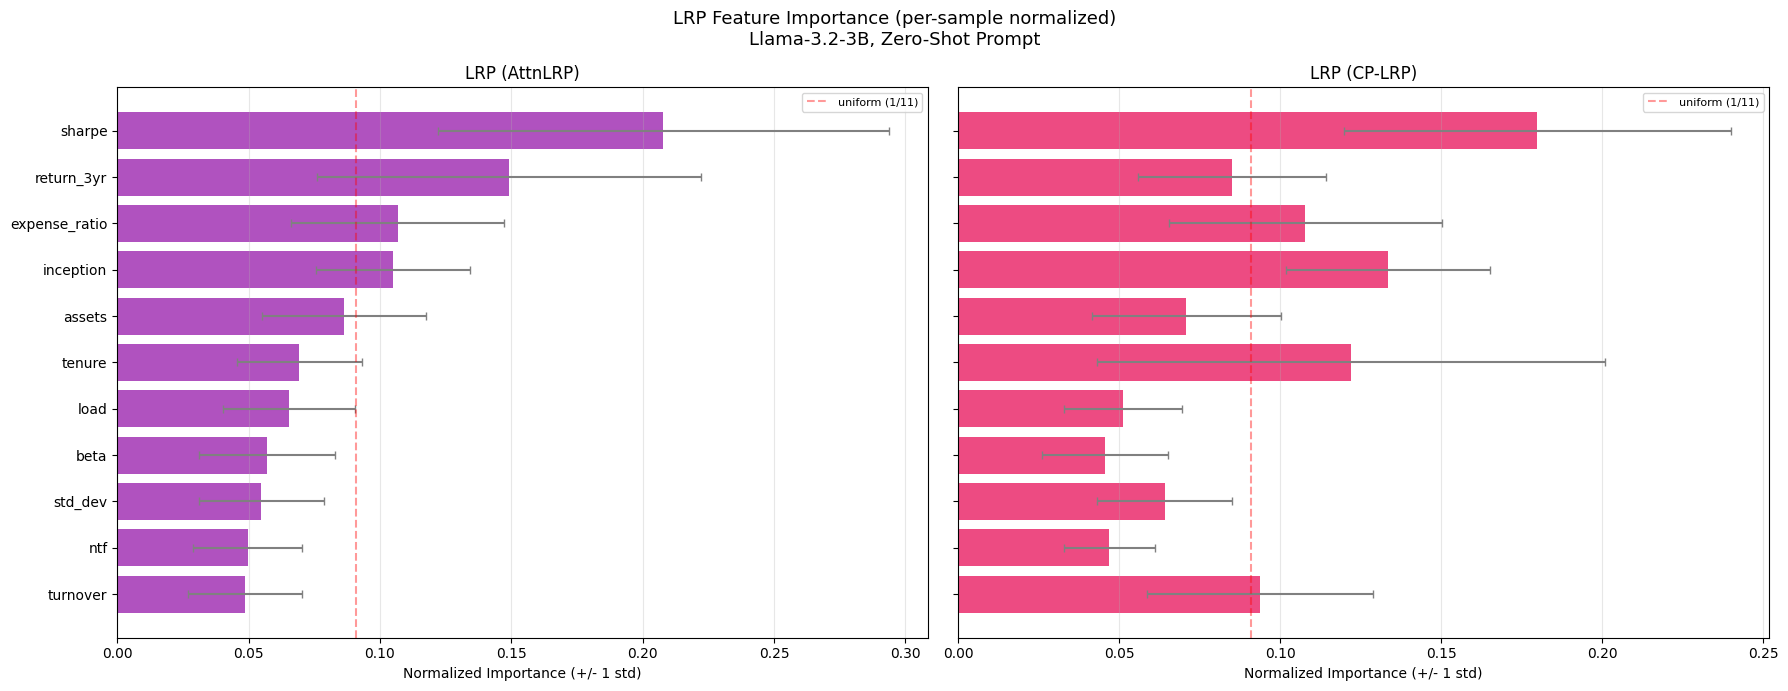

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/lrp_feature_importance_comparison.png


In [19]:
# Plot 1: Feature importance bar charts for both LRP variants
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, (imp_df, title, color) in zip(axes, [
    (attnlrp_importance, "LRP (AttnLRP)", "#9C27B0"),
    (cplrp_importance, "LRP (CP-LRP)", "#E91E63"),
]):
    if imp_df.empty:
        ax.set_title(f"{title} (no data)")
        continue
    data = imp_df.sort_values("mean_norm", ascending=True)
    ax.barh(data["feature"], data["mean_norm"], xerr=data["std_norm"],
            color=color, alpha=0.8, capsize=3, ecolor="gray")
    ax.set_xlabel("Normalized Importance (+/- 1 std)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    ax.axvline(x=1/11, color="red", linestyle="--", alpha=0.4, label="uniform (1/11)")
    ax.legend(fontsize=8)

plt.suptitle(
    "LRP Feature Importance (per-sample normalized)\n"
    "Llama-3.2-3B, Zero-Shot Prompt",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lrp_feature_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUT_DIR / 'lrp_feature_importance_comparison.png'}")

### 10.2 Per-Token Heatmap (Sample Prompts)

Visualize per-token relevance for the first few samples. Red = positive relevance (supports decision), blue = negative (opposes). This is unique to LRP -- the interpreto methods only report absolute values.

/tmp/ipykernel_5691/934617356.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("bwr")


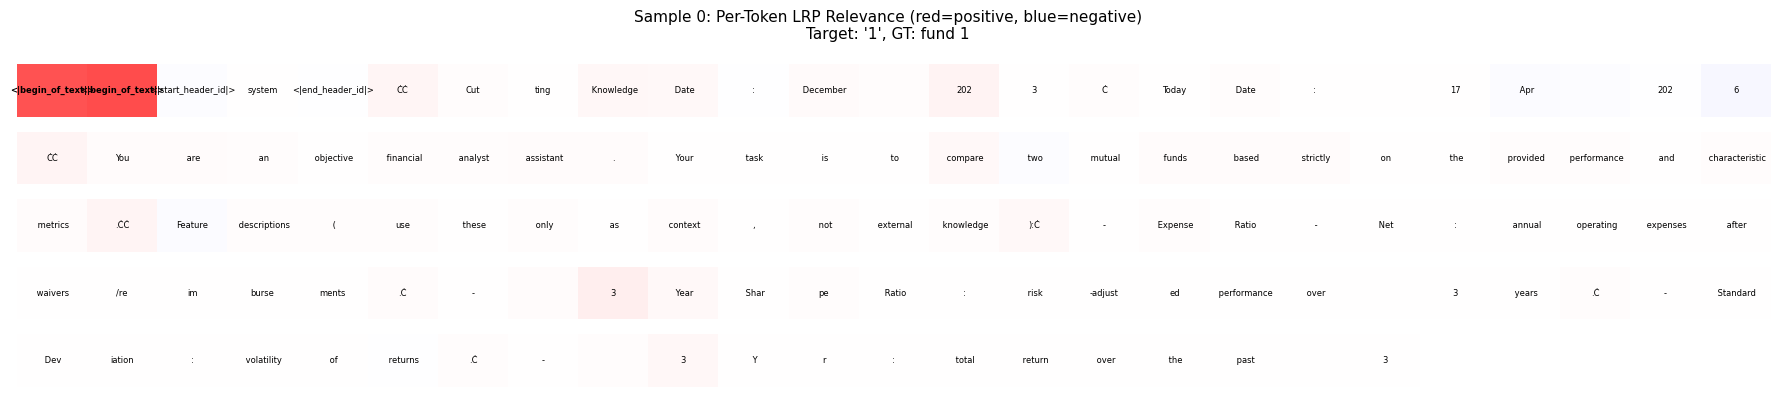

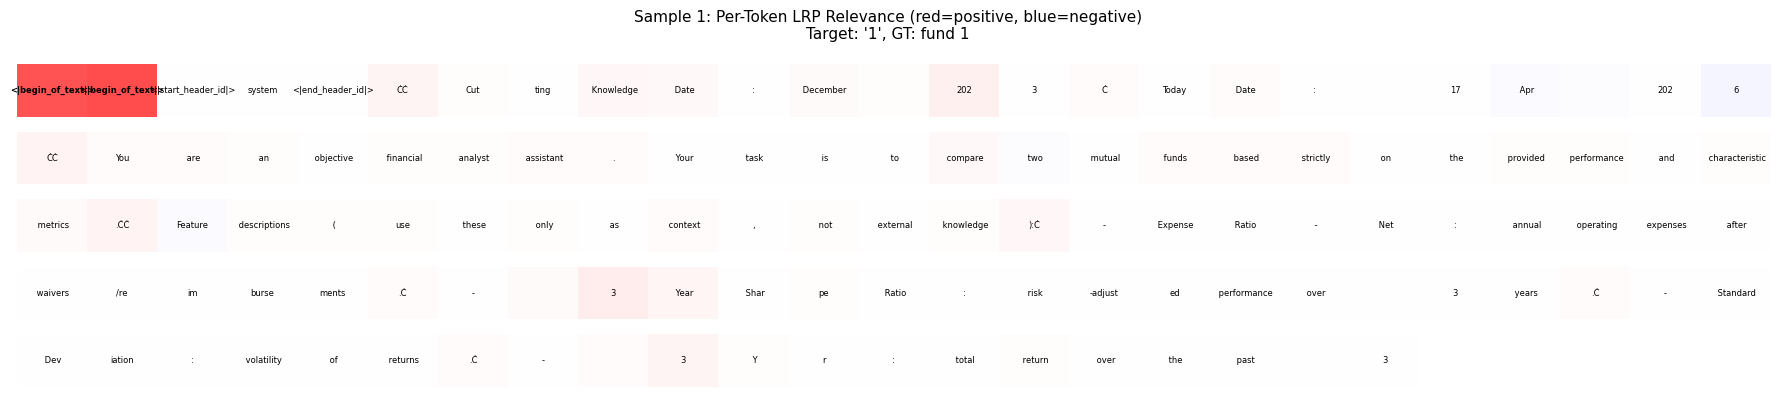

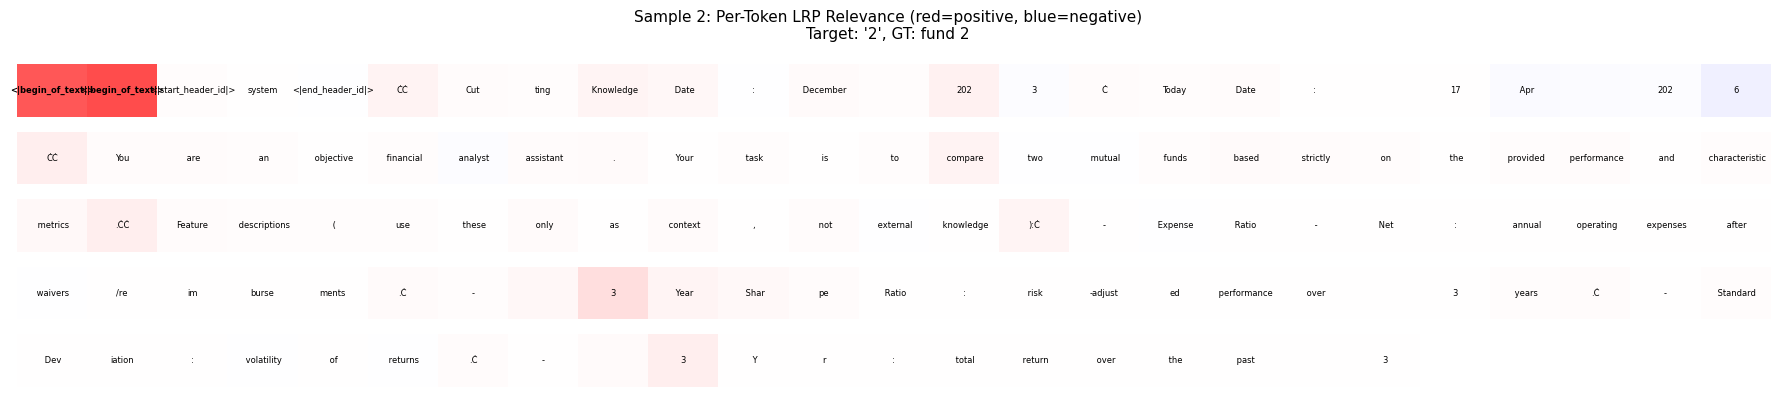

In [20]:
# Per-token heatmap using matplotlib (Colab-friendly, no LaTeX needed)
from matplotlib.colors import Normalize as MplNormalize
from matplotlib import cm

def plot_token_heatmap(relevance_np, prompt_text, tokenizer, sample_idx, output_dir,
                       max_tokens=120, figsize_per_row=(18, 0.6)):
    """Plot per-token relevance heatmap with colored tokens."""
    encoding = tokenizer(prompt_text, return_offsets_mapping=True, add_special_tokens=True)
    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
    offsets = encoding["offset_mapping"]

    # Limit to feature-region tokens for readability
    # Find where "Mutual fund 1:" starts in tokens
    start_idx = 0
    for idx, (cs, ce) in enumerate(offsets):
        text_at = prompt_text[cs:ce] if cs != ce else ""
        if "Mutual" in text_at:
            start_idx = max(0, idx - 2)
            break

    end_idx = min(start_idx + max_tokens, len(tokens))
    tokens_sub = tokens[start_idx:end_idx]
    rel_sub = relevance_np[start_idx:end_idx]

    # Normalize to [-1, 1]
    abs_max = np.abs(rel_sub).max()
    if abs_max > 0:
        rel_norm = rel_sub / abs_max
    else:
        rel_norm = rel_sub

    # Create heatmap
    cmap = cm.get_cmap("bwr")
    norm = MplNormalize(vmin=-1, vmax=1)

    # Wrap tokens into rows
    tokens_per_row = 25
    n_rows = (len(tokens_sub) + tokens_per_row - 1) // tokens_per_row

    fig, axes = plt.subplots(n_rows, 1, figsize=(figsize_per_row[0], figsize_per_row[1] * n_rows + 1))
    if n_rows == 1:
        axes = [axes]

    for row_idx in range(n_rows):
        ax = axes[row_idx]
        ax.set_xlim(0, tokens_per_row)
        ax.set_ylim(0, 1)
        ax.axis("off")

        row_start = row_idx * tokens_per_row
        row_end = min(row_start + tokens_per_row, len(tokens_sub))

        for j, tok_pos in enumerate(range(row_start, row_end)):
            color = cmap(norm(rel_norm[tok_pos]))
            token_text = tokens_sub[tok_pos].replace("▁", " ").replace("Ġ", " ")
            ax.add_patch(plt.Rectangle((j, 0), 1, 1, facecolor=color, alpha=0.7))
            ax.text(j + 0.5, 0.5, token_text, ha="center", va="center", fontsize=6,
                    fontweight="bold" if abs(rel_norm[tok_pos]) > 0.5 else "normal")

    plt.suptitle(
        f"Sample {sample_idx}: Per-Token LRP Relevance (red=positive, blue=negative)\n"
        f"Target: '{attribution_targets[sample_idx]}', GT: fund {int(ground_truths[sample_idx])}",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(output_dir / f"lrp_token_heatmap_sample{sample_idx}.png", dpi=150, bbox_inches="tight")
    plt.show()


# Plot heatmaps for first 3 samples
for i in range(min(3, len(raw_relevances))):
    if i in raw_relevances:
        plot_token_heatmap(raw_relevances[i], sentence_chat_prompts[i], tokenizer, i, OUTPUT_DIR)

### 10.3 Layer-Wise Relevance Heatmap

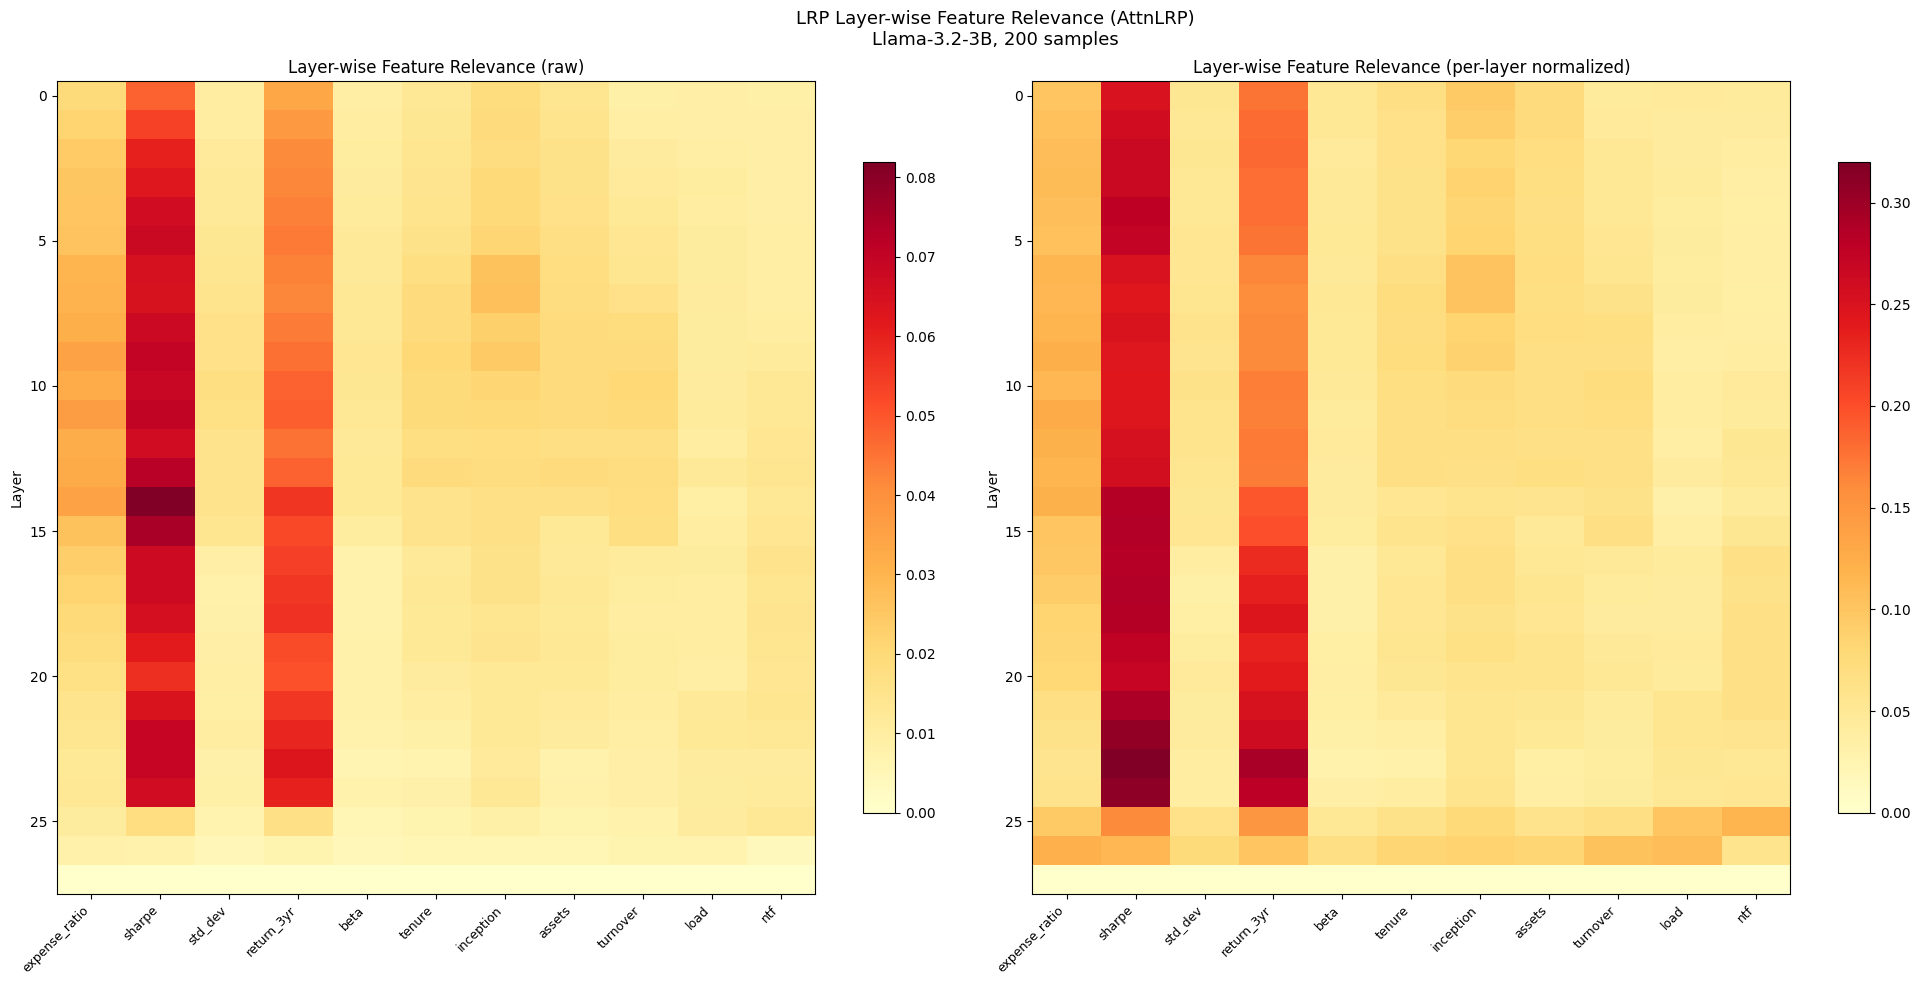

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/lrp_layer_feature_heatmap.png


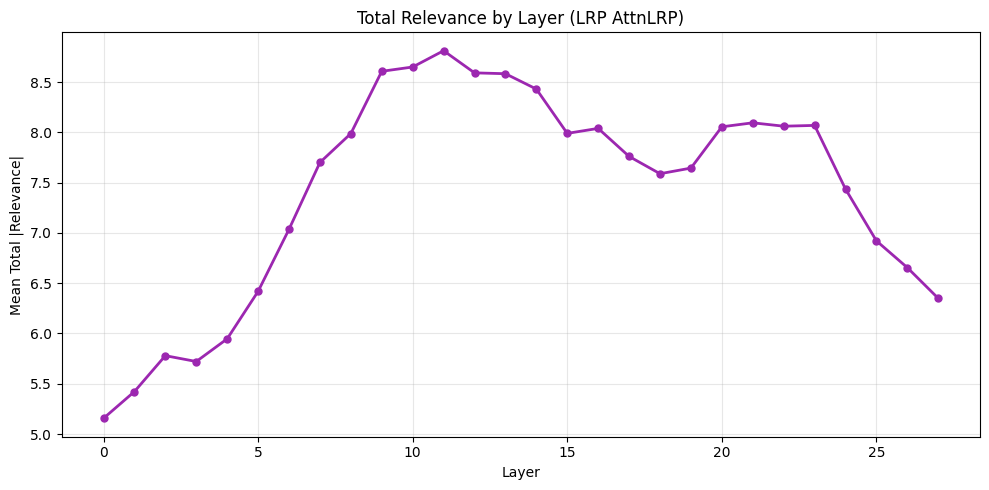

In [21]:
# Plot 3: Layer-wise feature relevance heatmap
if layer_feature_matrices:
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # Raw heatmap
    im1 = axes[0].imshow(avg_layer_feature, aspect="auto", cmap="YlOrRd")
    axes[0].set_xticks(range(len(FEATURE_SHORT_NAMES)))
    axes[0].set_xticklabels(FEATURE_SHORT_NAMES, rotation=45, ha="right", fontsize=9)
    axes[0].set_ylabel("Layer")
    axes[0].set_title("Layer-wise Feature Relevance (raw)")
    plt.colorbar(im1, ax=axes[0], shrink=0.8)

    # Normalized heatmap (each layer sums to 1)
    im2 = axes[1].imshow(avg_layer_feature_norm, aspect="auto", cmap="YlOrRd")
    axes[1].set_xticks(range(len(FEATURE_SHORT_NAMES)))
    axes[1].set_xticklabels(FEATURE_SHORT_NAMES, rotation=45, ha="right", fontsize=9)
    axes[1].set_ylabel("Layer")
    axes[1].set_title("Layer-wise Feature Relevance (per-layer normalized)")
    plt.colorbar(im2, ax=axes[1], shrink=0.8)

    plt.suptitle(
        f"LRP Layer-wise Feature Relevance (AttnLRP)\n"
        f"Llama-3.2-3B, {len(layer_feature_matrices)} samples",
        fontsize=13,
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "lrp_layer_feature_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {OUTPUT_DIR / 'lrp_layer_feature_heatmap.png'}")

    # Plot total relevance by layer
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(N_LAYERS), avg_layer_totals, "o-", color="#9C27B0", linewidth=2, markersize=5)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean Total |Relevance|")
    ax.set_title("Total Relevance by Layer (LRP AttnLRP)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "lrp_total_relevance_by_layer.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No layer-wise data available.")

### 10.4 Layer-Wise LRP Relevance vs Linear Probe Accuracy

Overlay LRP relevance per layer with the linear probe accuracy per layer from the probing experiments. This tests whether layers that encode feature information (high probe accuracy) also assign high LRP relevance.

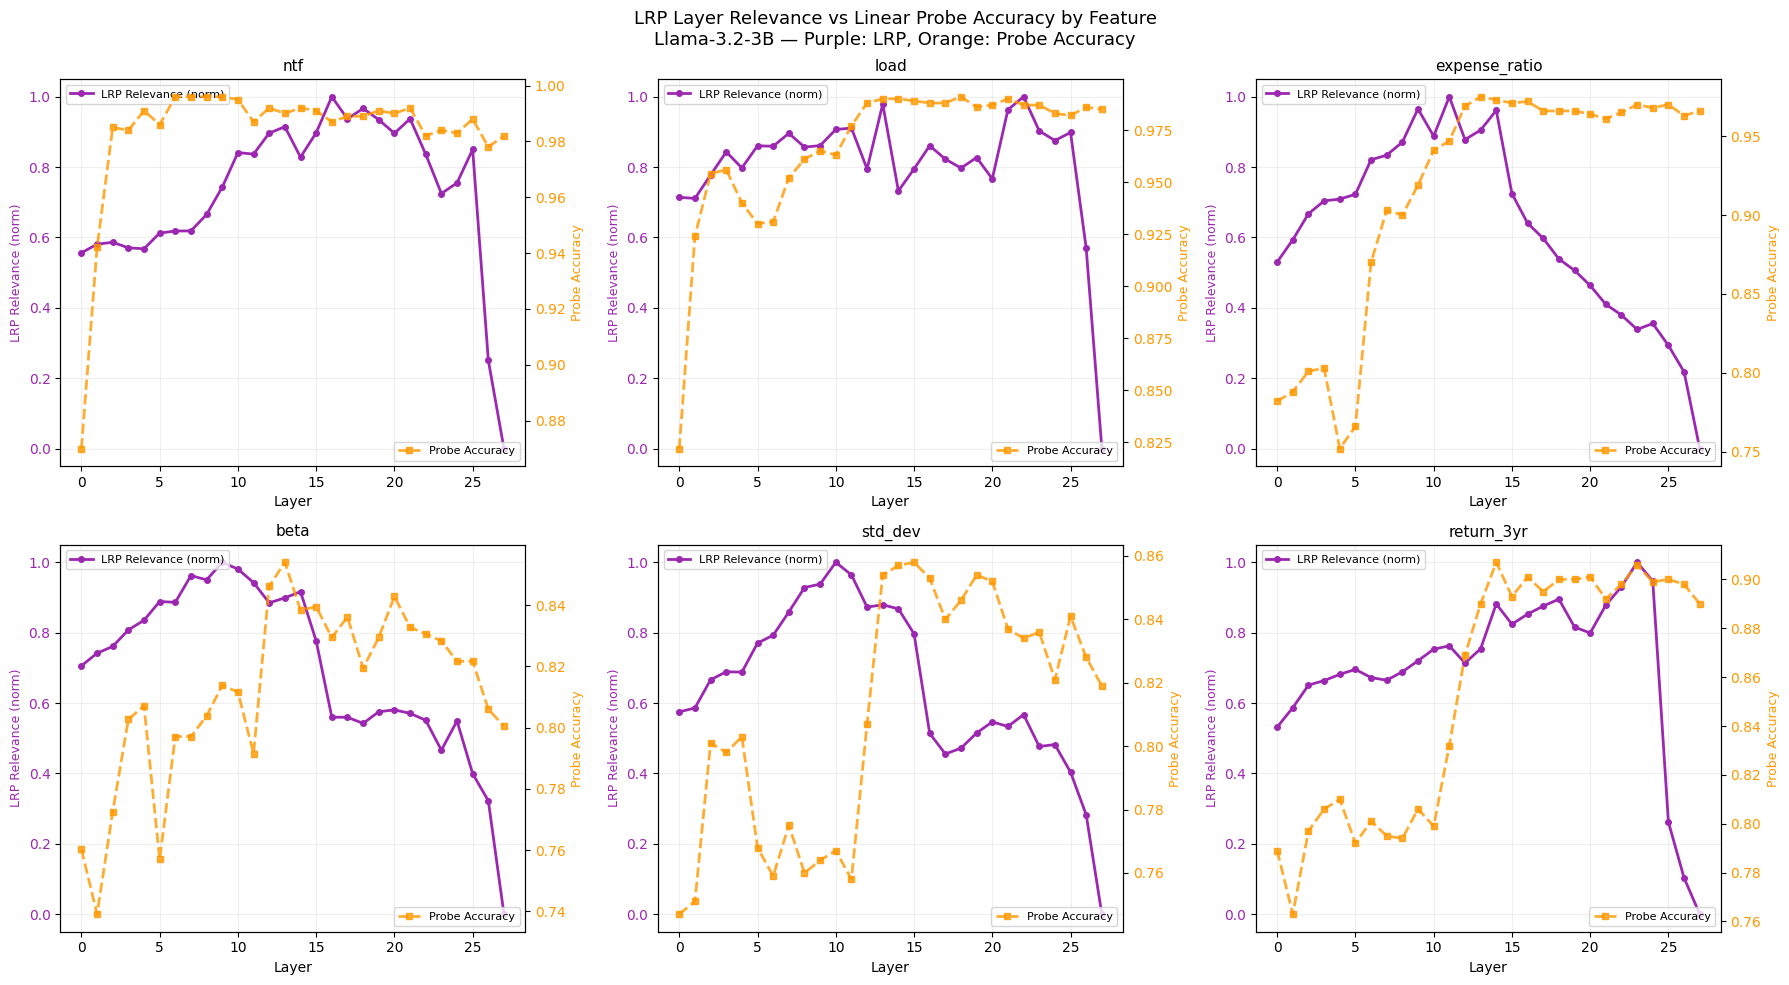

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/lrp_vs_probe_by_layer.png

Per-layer Spearman correlation (LRP relevance vs probe accuracy):
 layer  spearman_rho  p_value
     0     -0.236903 0.483065
     1     -0.163636 0.630685
     2     -0.437359 0.178561
     3     -0.281818 0.401145
     4     -0.300000 0.370083
     5     -0.354545 0.284693
     6     -0.318182 0.340298
     7     -0.336364 0.311824
     8     -0.372727 0.258926
     9     -0.400000 0.222868
    10     -0.327273 0.325895
    11     -0.200000 0.555445
    12     -0.072727 0.831716
    13     -0.114156 0.738221
    14     -0.100000 0.769875
    15     -0.059226 0.862673
    16      0.337131 0.310652
    17      0.332575 0.317648
    18      0.496584 0.120235
    19      0.469250 0.145364
    20      0.409091 0.211545
    21      0.690909 0.018565
    22      0.663636 0.025984
    23      0.600000 0.051003
    24      0.523919 0.098083
    25      0.618182 0.042646
    26      

/tmp/ipykernel_5691/3027269692.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(lrp_vals[valid], probe_vals[valid])


In [22]:
# Load probe matrix accuracy data
probe_matrix_path = PROJECT_ROOT / "data" / "probe_results" / "probe_matrix_accuracy_llama-3.2-3b_2_fewshot_cot_temp0.csv"

# Map probe feature names to short names
probe_feat_map = {
    "expense_ratio_f1_lower": "expense_ratio",
    "sharpe_f1_higher": "sharpe",
    "stdev_f1_lower": "std_dev",
    "return_3yr_f1_higher": "return_3yr",
    "beta_f1_lower": "beta",
    "tenure_f1_longer": "tenure",
    "inception_f1_older": "inception",
    "assets_f1_higher": "assets",
    "turnover_f1_lower": "turnover",
    "load_f1_no": "load",
    "ntf_f1_yes": "ntf",
}

if probe_matrix_path.exists() and layer_feature_matrices:
    probe_matrix_df = pd.read_csv(probe_matrix_path)

    # Select a subset of informative features for the overlay plot
    features_to_plot = ["ntf", "load", "expense_ratio", "beta", "std_dev", "return_3yr"]

    n_feat = len(features_to_plot)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, feat in enumerate(features_to_plot):
        ax = axes[idx]

        # LRP relevance by layer
        feat_idx = FEATURE_SHORT_NAMES.index(feat)
        lrp_by_layer = avg_layer_feature[:, feat_idx]

        # Normalize LRP to [0, 1] for visual comparability
        lrp_max = lrp_by_layer.max()
        lrp_norm = lrp_by_layer / lrp_max if lrp_max > 0 else lrp_by_layer

        ax.plot(range(N_LAYERS), lrp_norm, "o-", color="#9C27B0", linewidth=2, markersize=4,
                label="LRP Relevance (norm)")

        # Probe accuracy by layer
        probe_col = [k for k, v in probe_feat_map.items() if v == feat]
        if probe_col and probe_col[0] in probe_matrix_df.columns:
            probe_acc = probe_matrix_df[probe_col[0]].values[:N_LAYERS]
            ax2 = ax.twinx()
            ax2.plot(range(len(probe_acc)), probe_acc, "s--", color="#FF9800", linewidth=2, markersize=4,
                     label="Probe Accuracy", alpha=0.8)
            ax2.set_ylabel("Probe Accuracy", color="#FF9800", fontsize=9)
            ax2.tick_params(axis="y", labelcolor="#FF9800")
            ax2.legend(loc="lower right", fontsize=8)

        ax.set_xlabel("Layer")
        ax.set_ylabel("LRP Relevance (norm)", color="#9C27B0", fontsize=9)
        ax.tick_params(axis="y", labelcolor="#9C27B0")
        ax.set_title(feat, fontsize=11)
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(alpha=0.2)

    plt.suptitle(
        "LRP Layer Relevance vs Linear Probe Accuracy by Feature\n"
        "Llama-3.2-3B — Purple: LRP, Orange: Probe Accuracy",
        fontsize=13,
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "lrp_vs_probe_by_layer.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {OUTPUT_DIR / 'lrp_vs_probe_by_layer.png'}")

    # Compute per-layer correlation between LRP relevance and probe accuracy
    layer_correlations = []
    for l in range(N_LAYERS):
        lrp_vals = avg_layer_feature[l, :]  # 11 features
        probe_vals = []
        for feat in FEATURE_SHORT_NAMES:
            probe_col = [k for k, v in probe_feat_map.items() if v == feat]
            if probe_col and probe_col[0] in probe_matrix_df.columns:
                probe_vals.append(probe_matrix_df[probe_col[0]].iloc[l] if l < len(probe_matrix_df) else np.nan)
            else:
                probe_vals.append(np.nan)
        probe_vals = np.array(probe_vals)
        valid = ~np.isnan(probe_vals)
        if valid.sum() > 3:
            rho, p = spearmanr(lrp_vals[valid], probe_vals[valid])
            layer_correlations.append({"layer": l, "spearman_rho": rho, "p_value": p})
        else:
            layer_correlations.append({"layer": l, "spearman_rho": np.nan, "p_value": np.nan})

    corr_df = pd.DataFrame(layer_correlations)
    print("\nPer-layer Spearman correlation (LRP relevance vs probe accuracy):")
    print(corr_df.to_string(index=False))
    corr_df.to_csv(OUTPUT_DIR / "lrp_probe_layer_correlation.csv", index=False)
else:
    print("Probe matrix or layer-wise data not available for overlay plot.")

### 10.5 Signed Relevance Analysis (LRP-Unique)

LRP provides signed relevance: positive tokens support the decision, negative tokens oppose it. This analysis is unique to LRP -- interpreto methods only report absolute values.

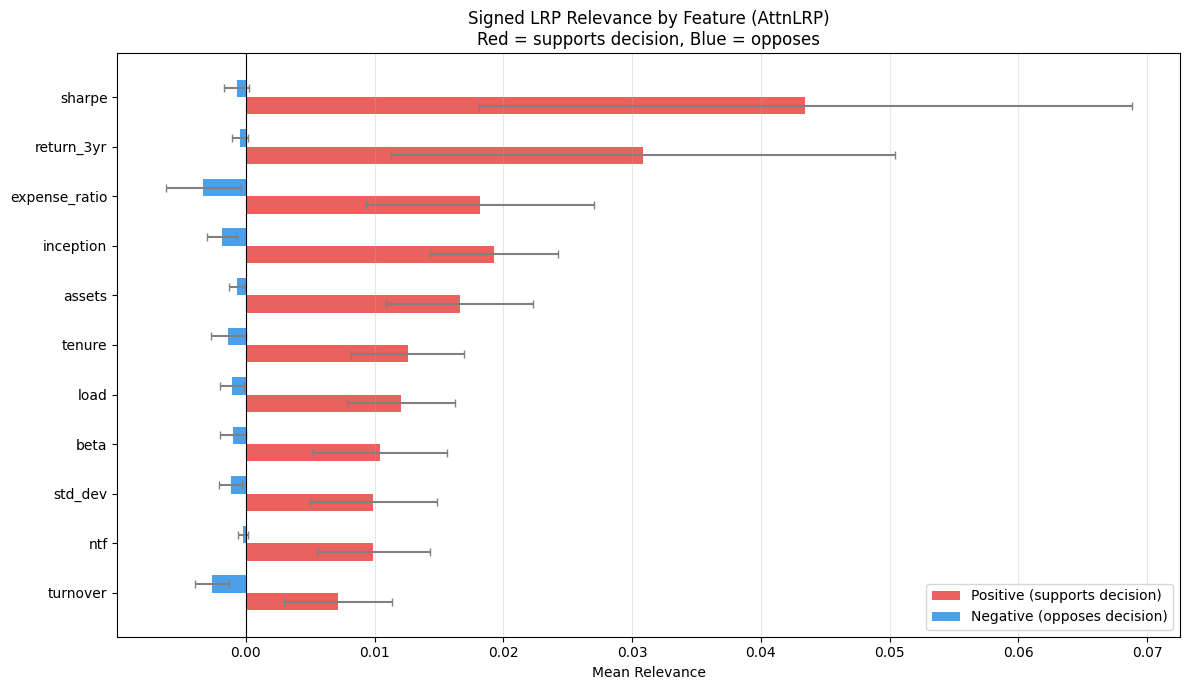

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/lrp_signed_relevance.png

Sign ratio summary (positive / total absolute):
    expense_ratio: 84.6% positive, 15.4% negative
           sharpe: 98.4% positive, 1.6% negative
          std_dev: 89.4% positive, 10.6% negative
       return_3yr: 98.5% positive, 1.5% negative
             beta: 91.1% positive, 8.9% negative
           tenure: 90.3% positive, 9.7% negative
        inception: 91.4% positive, 8.6% negative
           assets: 96.0% positive, 4.0% negative
         turnover: 73.3% positive, 26.7% negative
             load: 91.8% positive, 8.2% negative
              ntf: 97.8% positive, 2.2% negative


In [23]:
# Signed relevance analysis
if signed_relevances:
    pos_means = {feat: [] for feat in FEATURE_SHORT_NAMES}
    neg_means = {feat: [] for feat in FEATURE_SHORT_NAMES}

    for i, scores in signed_relevances.items():
        for feat in FEATURE_SHORT_NAMES:
            pos_means[feat].append(scores[feat]["positive"])
            neg_means[feat].append(scores[feat]["negative"])

    fig, ax = plt.subplots(figsize=(12, 7))
    x = np.arange(len(FEATURE_SHORT_NAMES))
    width = 0.35

    pos_vals = [np.mean(pos_means[f]) for f in FEATURE_SHORT_NAMES]
    neg_vals = [np.mean(neg_means[f]) for f in FEATURE_SHORT_NAMES]  # negative values
    pos_stds = [np.std(pos_means[f]) for f in FEATURE_SHORT_NAMES]
    neg_stds = [np.std(neg_means[f]) for f in FEATURE_SHORT_NAMES]

    # Sort by total (pos + |neg|)
    total_vals = [p + abs(n) for p, n in zip(pos_vals, neg_vals)]
    sort_idx = np.argsort(total_vals)

    sorted_feats = [FEATURE_SHORT_NAMES[i] for i in sort_idx]
    sorted_pos = [pos_vals[i] for i in sort_idx]
    sorted_neg = [neg_vals[i] for i in sort_idx]
    sorted_pos_std = [pos_stds[i] for i in sort_idx]
    sorted_neg_std = [neg_stds[i] for i in sort_idx]

    ax.barh(x - width/2, sorted_pos, width, xerr=sorted_pos_std,
            label="Positive (supports decision)", color="#E53935", alpha=0.8, capsize=3, ecolor="gray")
    ax.barh(x + width/2, sorted_neg, width, xerr=sorted_neg_std,
            label="Negative (opposes decision)", color="#1E88E5", alpha=0.8, capsize=3, ecolor="gray")

    ax.set_yticks(x)
    ax.set_yticklabels(sorted_feats)
    ax.set_xlabel("Mean Relevance")
    ax.set_title("Signed LRP Relevance by Feature (AttnLRP)\nRed = supports decision, Blue = opposes")
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.legend()
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "lrp_signed_relevance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {OUTPUT_DIR / 'lrp_signed_relevance.png'}")

    # Print sign ratio summary
    print("\nSign ratio summary (positive / total absolute):")
    for feat in FEATURE_SHORT_NAMES:
        p = np.mean(pos_means[feat])
        n = abs(np.mean(neg_means[feat]))
        ratio = p / (p + n) if (p + n) > 0 else 0
        print(f"  {feat:>15s}: {ratio:.1%} positive, {1-ratio:.1%} negative")

### 10.6 Fund 1 vs Fund 2 Attribution

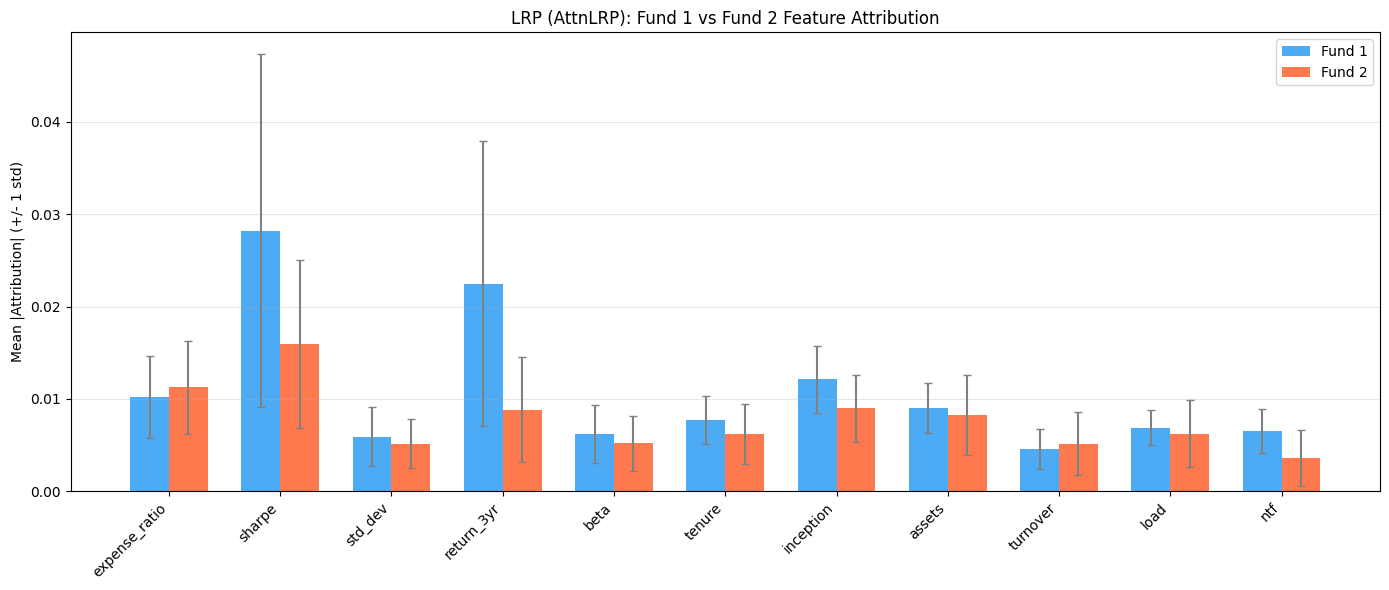

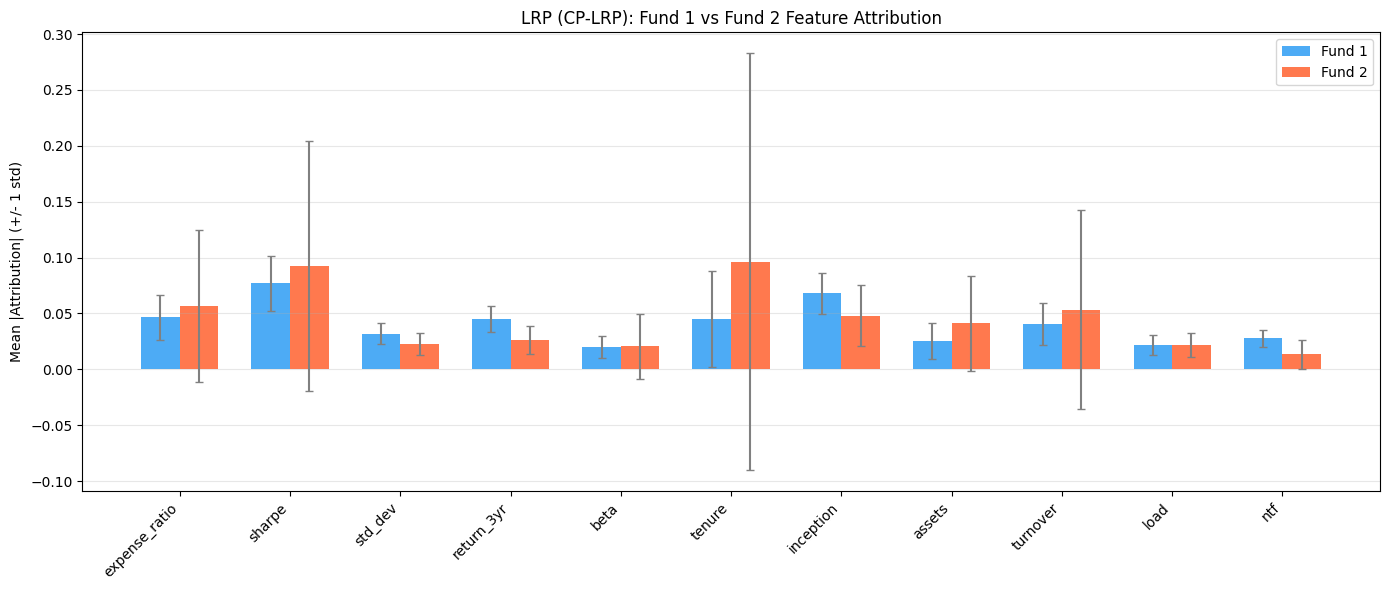

In [24]:
def plot_fund1_vs_fund2(results_list, method_name, output_dir):
    if not results_list:
        print(f"No results for {method_name}")
        return

    fund1_means, fund2_means = [], []
    fund1_stds, fund2_stds = [], []
    for feat in FEATURE_SHORT_NAMES:
        f1_vals = [r["feature_scores"][feat]["fund1"] for r in results_list]
        f2_vals = [r["feature_scores"][feat]["fund2"] for r in results_list]
        fund1_means.append(np.mean(f1_vals))
        fund2_means.append(np.mean(f2_vals))
        fund1_stds.append(np.std(f1_vals))
        fund2_stds.append(np.std(f2_vals))

    x = np.arange(len(FEATURE_SHORT_NAMES))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x - width/2, fund1_means, width, yerr=fund1_stds,
           label="Fund 1", color="#2196F3", alpha=0.8, capsize=3, ecolor="gray")
    ax.bar(x + width/2, fund2_means, width, yerr=fund2_stds,
           label="Fund 2", color="#FF5722", alpha=0.8, capsize=3, ecolor="gray")
    ax.set_xticks(x)
    ax.set_xticklabels(FEATURE_SHORT_NAMES, rotation=45, ha="right")
    ax.set_ylabel("Mean |Attribution| (+/- 1 std)")
    ax.set_title(f"{method_name}: Fund 1 vs Fund 2 Feature Attribution")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    safe_name = method_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(output_dir / f"fund1_vs_fund2_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_fund1_vs_fund2(lrp_results, "LRP (AttnLRP)", OUTPUT_DIR)
plot_fund1_vs_fund2(cplrp_results, "LRP (CP-LRP)", OUTPUT_DIR)

## 11. Cross-Method Comparison

Load the interpreto attribution results and merge with LRP results for a 5-method comparison (IG, SHAP, Occlusion, AttnLRP, CP-LRP).

In [25]:
# Load interpreto results
interpreto_path = PROJECT_ROOT / "interpreto_attributions" / "results" / "feature_importance_all_methods.csv"

if interpreto_path.exists():
    interpreto_df = pd.read_csv(interpreto_path)
    print(f"Loaded interpreto results: {len(interpreto_df)} rows, methods: {interpreto_df['method'].unique()}")

    # Combine all methods
    all_methods = pd.concat([interpreto_df, lrp_combined], ignore_index=True)
    all_methods.to_csv(OUTPUT_DIR / "feature_importance_all_methods_with_lrp.csv", index=False)
    print(f"Saved combined results to {OUTPUT_DIR / 'feature_importance_all_methods_with_lrp.csv'}")

    # Rank comparison table
    rank_pivot = all_methods.pivot(index="feature", columns="method", values="rank")
    print("\nFeature Ranking Comparison (1 = most important):")
    print(rank_pivot.to_string())

    # Normalized importance pivot
    norm_pivot = all_methods.pivot(index="feature", columns="method", values="mean_norm")
    print("\nNormalized Feature Importance:")
    print(norm_pivot.round(4).to_string())

    # Cross-method rank correlations
    methods = all_methods["method"].unique()
    print("\n\nPairwise Spearman Rank Correlations:")
    print(f"{'Method Pair':<50s}  {'rho':>6s}  {'p':>8s}  {'tau':>6s}  {'p_tau':>8s}")
    print("-" * 80)
    for i, m1 in enumerate(methods):
        for m2 in methods[i+1:]:
            r1 = all_methods[all_methods["method"] == m1].set_index("feature")["rank"]
            r2 = all_methods[all_methods["method"] == m2].set_index("feature")["rank"]
            common = r1.index.intersection(r2.index)
            if len(common) > 3:
                rho, p = spearmanr(r1[common], r2[common])
                tau, p_tau = kendalltau(r1[common], r2[common])
                print(f"{m1} vs {m2:<30s}  {rho:6.3f}  {p:8.4f}  {tau:6.3f}  {p_tau:8.4f}")

    # Consensus ranking across all 5 methods
    avg_rank = all_methods.groupby("feature")["rank"].mean().sort_values()
    print("\n\nConsensus Feature Ranking (avg rank across all methods):")
    for pos, (feat, avg_r) in enumerate(avg_rank.items(), 1):
        avg_norm = all_methods[all_methods["feature"] == feat]["mean_norm"].mean()
        print(f"  {pos:2d}. {feat:15s}  avg_rank={avg_r:.1f}  avg_norm={avg_norm:.4f}")
else:
    print(f"Interpreto results not found at {interpreto_path}")
    print("Showing LRP-only ranking comparison:")
    rank_pivot = lrp_combined.pivot(index="feature", columns="method", values="rank")
    print(rank_pivot.to_string())

Loaded interpreto results: 33 rows, methods: ['Integrated Gradients' 'KernelSHAP' 'Occlusion']
Saved combined results to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/feature_importance_all_methods_with_lrp.csv

Feature Ranking Comparison (1 = most important):
method         Integrated Gradients  KernelSHAP  LRP (AttnLRP)  LRP (CP-LRP)  Occlusion
feature                                                                                
assets                            5           3              5             7          9
beta                              8           8              8            11          2
expense_ratio                     2           4              3             4          7
inception                         6           7              4             2          5
load                              3           5              7             9          3
ntf                               1           1             10            10          1
retur

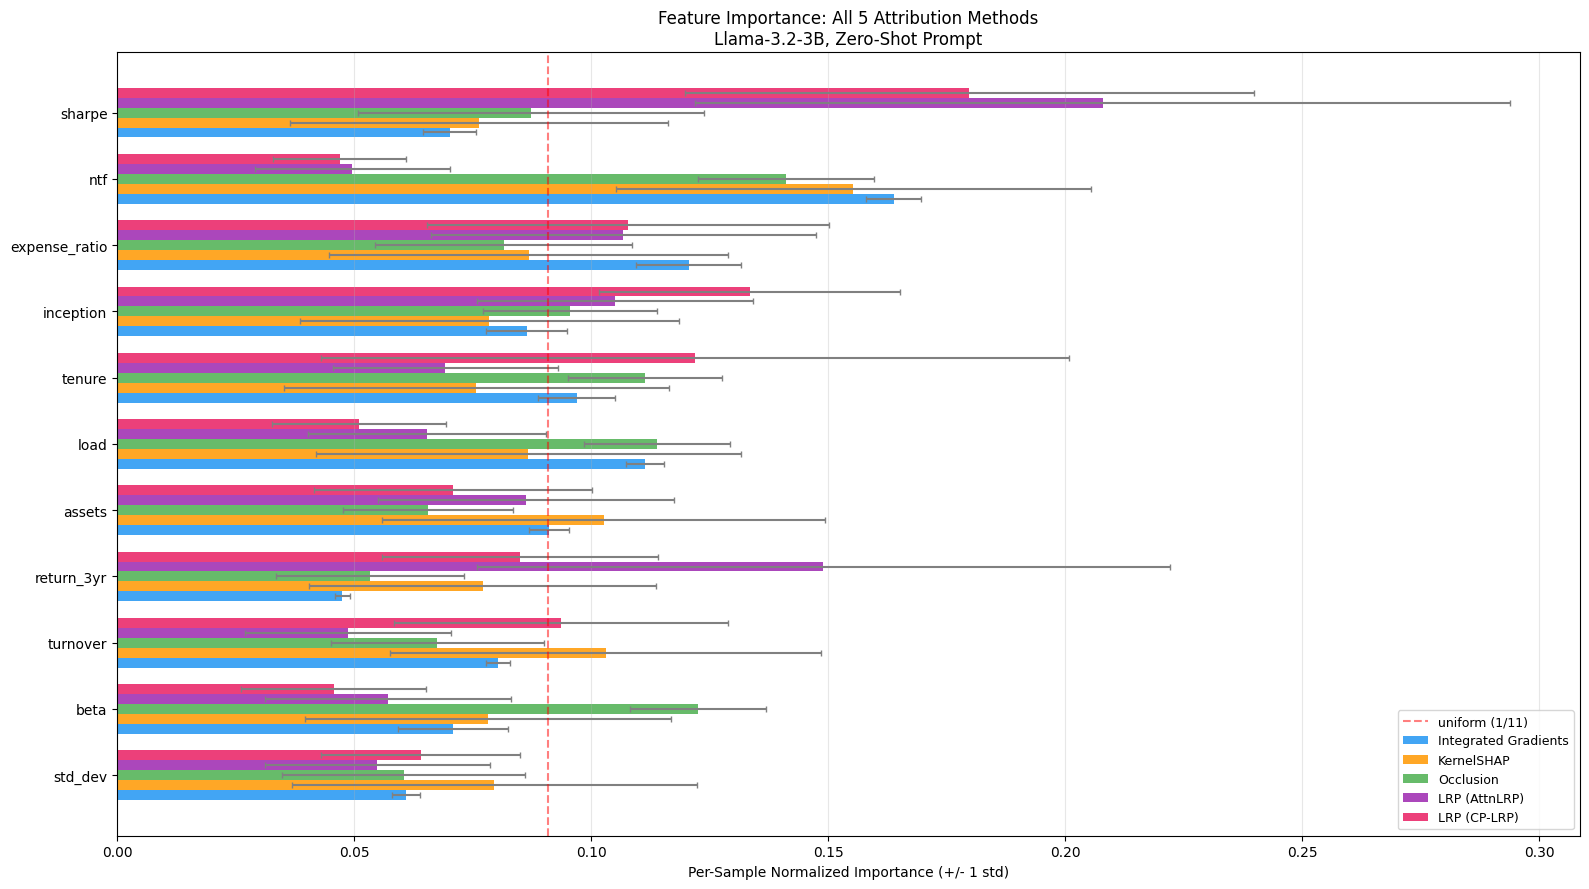

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/all_methods_feature_importance.png


In [26]:
# All-methods comparison bar chart (5 methods)
if interpreto_path.exists():
    fig, ax = plt.subplots(figsize=(16, 9))

    method_names = ["Integrated Gradients", "KernelSHAP", "Occlusion", "LRP (AttnLRP)", "LRP (CP-LRP)"]
    colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0", "#E91E63"]
    width = 0.15

    # Sort features by average importance across all methods
    avg_norm = all_methods.groupby("feature")["mean_norm"].mean().sort_values(ascending=True)
    feature_order = avg_norm.index.tolist()
    y_pos = np.arange(len(feature_order))

    for j, (method, color) in enumerate(zip(method_names, colors)):
        method_data = all_methods[all_methods["method"] == method]
        if method_data.empty:
            continue
        vals = []
        errs = []
        for feat in feature_order:
            row = method_data[method_data["feature"] == feat]
            vals.append(row["mean_norm"].values[0] if len(row) > 0 else 0)
            errs.append(row["std_norm"].values[0] if len(row) > 0 else 0)
        ax.barh(y_pos + j * width, vals, width, xerr=errs,
                label=method, color=color, alpha=0.85, capsize=2, ecolor="gray")

    ax.axvline(x=1/11, color="red", linestyle="--", alpha=0.5, label="uniform (1/11)")
    ax.set_yticks(y_pos + width * 2)
    ax.set_yticklabels(feature_order)
    ax.set_xlabel("Per-Sample Normalized Importance (+/- 1 std)")
    ax.set_title(
        "Feature Importance: All 5 Attribution Methods\n"
        "Llama-3.2-3B, Zero-Shot Prompt"
    )
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "all_methods_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {OUTPUT_DIR / 'all_methods_feature_importance.png'}")

## 11.5. Bootstrap Confidence Intervals on Feature Rankings

Quantify uncertainty in feature rankings via **1,000 bootstrap resamples**. For each resample, draw N samples with replacement from the per-sample normalized importance scores, compute the mean, and rank features. Reports median rank, 95% CI, P(rank #1), and P(top 3) for each feature and LRP variant. This analysis is only possible for LRP methods (where we have per-sample attribution data); the interpreto methods only provide aggregated means/stds.


Bootstrap Rankings: LRP (AttnLRP) (1000 resamples, 500 samples)
        Feature  Median        95% CI   P(#1)  P(top3)    Mean    Std
         sharpe       2  [   2,    2]    0.0%   100.0%     2.0    0.0
     return_3yr       3  [   3,    3]    0.0%   100.0%     3.0    0.0
  expense_ratio       4  [   4,    5]    0.0%     0.0%     4.2    0.4
      inception       5  [   4,    5]    0.0%     0.0%     4.8    0.4
         assets       6  [   6,    6]    0.0%     0.0%     6.0    0.0
         tenure       7  [   7,    7]    0.0%     0.0%     7.0    0.1
           load       8  [   8,    8]    0.0%     0.0%     8.0    0.1
           beta       9  [   9,   10]    0.0%     0.0%     9.1    0.3
        std_dev      10  [   9,   10]    0.0%     0.0%     9.9    0.3
            ntf      11  [  11,   12]    0.0%     0.0%    11.2    0.4
       turnover      12  [  11,   12]    0.0%     0.0%    11.8    0.4

Bootstrap Rankings: LRP (CP-LRP) (1000 resamples, 500 samples)
        Feature  Median        

/tmp/ipykernel_5691/477295518.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, vert=False, patch_artist=True, labels=features_sorted,
/tmp/ipykernel_5691/477295518.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, vert=False, patch_artist=True, labels=features_sorted,
/tmp/ipykernel_5691/477295518.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, vert=False, patch_artist=True, labels=features_sorted,
/tmp/ipykernel_5691/477295518.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_lab

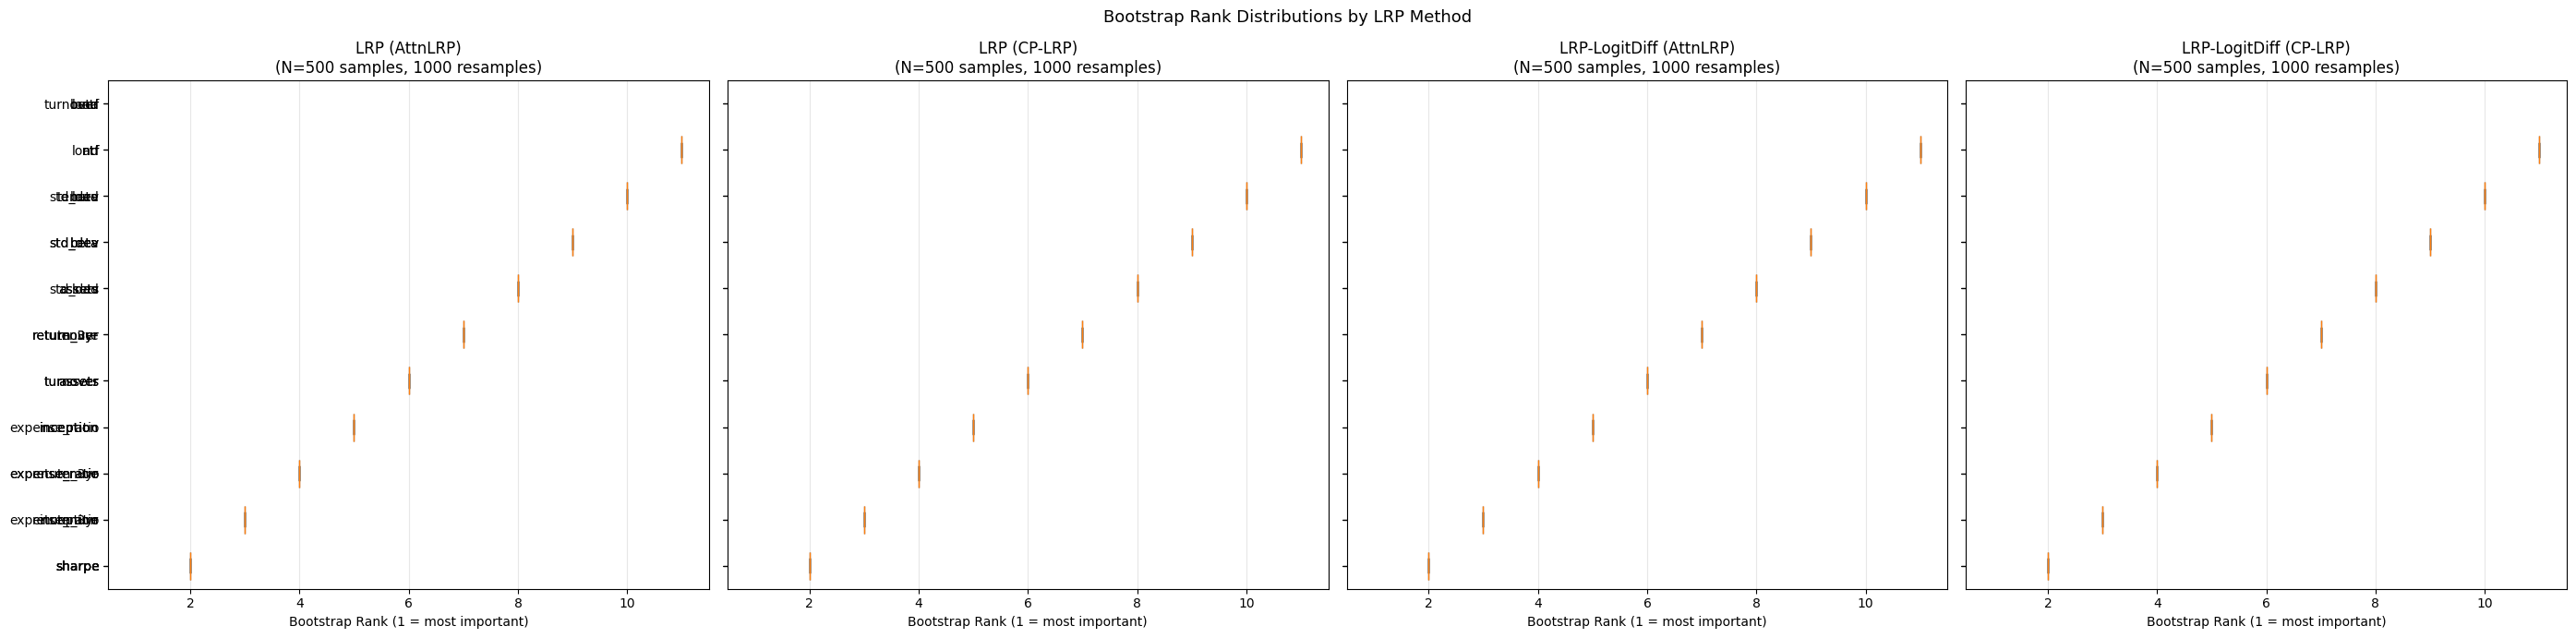

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/lrp_attributions/results/bootstrap_rank_distributions.png


In [27]:
# Bootstrap Confidence Intervals on Feature Rankings
# Uses per-sample normalized importance scores from all 4 LRP result sets

N_BOOTSTRAP = 1000
rng = np.random.RandomState(42)


def bootstrap_rankings(results_list, method_name, n_bootstrap=N_BOOTSTRAP):
    """
    Compute bootstrap confidence intervals on feature rankings.

    Returns a DataFrame with: feature, median_rank, rank_2.5, rank_97.5,
    p_rank1 (fraction of resamples where feature is #1),
    p_top3 (fraction of resamples where feature is in top 3).
    """
    if not results_list:
        return pd.DataFrame()

    n = len(results_list)
    norm_matrix = np.zeros((n, len(FEATURE_SHORT_NAMES)))
    for i, r in enumerate(results_list):
        fs = r["feature_scores"]
        sample_total = sum(fs[f]["total"] for f in FEATURE_SHORT_NAMES)
        for j, feat in enumerate(FEATURE_SHORT_NAMES):
            norm_matrix[i, j] = fs[feat]["total"] / sample_total if sample_total > 0 else 0

    rank_matrix = np.zeros((n_bootstrap, len(FEATURE_SHORT_NAMES)))
    for b in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        boot_means = norm_matrix[idx].mean(axis=0)
        rank_matrix[b] = len(FEATURE_SHORT_NAMES) + 1 - boot_means.argsort().argsort()

    records = []
    for j, feat in enumerate(FEATURE_SHORT_NAMES):
        ranks = rank_matrix[:, j]
        records.append({
            "feature": feat,
            "method": method_name,
            "median_rank": np.median(ranks),
            "rank_2.5": np.percentile(ranks, 2.5),
            "rank_97.5": np.percentile(ranks, 97.5),
            "p_rank1": (ranks == 1).mean(),
            "p_top3": (ranks <= 3).mean(),
            "mean_rank": ranks.mean(),
            "std_rank": ranks.std(),
        })

    return pd.DataFrame(records).sort_values("median_rank").reset_index(drop=True)


# Run bootstrap for all 4 LRP result sets
bootstrap_configs = [
    (lrp_results, "LRP (AttnLRP)"),
    (cplrp_results, "LRP (CP-LRP)"),
    (logitdiff_results, "LRP-LogitDiff (AttnLRP)"),
]
if "logitdiff_cplrp_results" in dir() and logitdiff_cplrp_results:
    bootstrap_configs.append((logitdiff_cplrp_results, "LRP-LogitDiff (CP-LRP)"))

all_bootstrap = []
for results, name in bootstrap_configs:
    if not results:
        continue
    boot_df = bootstrap_rankings(results, name)
    all_bootstrap.append(boot_df)

    print(f"\n{'=' * 70}")
    print(f"Bootstrap Rankings: {name} ({N_BOOTSTRAP} resamples, {len(results)} samples)")
    print(f"{'=' * 70}")
    print(f"{'Feature':>15s}  {'Median':>6s}  {'95% CI':>12s}  {'P(#1)':>6s}  {'P(top3)':>7s}  "
          f"{'Mean':>6s}  {'Std':>5s}")
    for _, row in boot_df.iterrows():
        print(f"{row['feature']:>15s}  {row['median_rank']:6.0f}  "
              f"[{row['rank_2.5']:4.0f}, {row['rank_97.5']:4.0f}]  "
              f"{row['p_rank1']:6.1%}  {row['p_top3']:7.1%}  "
              f"{row['mean_rank']:6.1f}  {row['std_rank']:5.1f}")

if all_bootstrap:
    bootstrap_combined = pd.concat(all_bootstrap, ignore_index=True)
    bootstrap_combined.to_csv(OUTPUT_DIR / "bootstrap_ranking_confidence_intervals.csv", index=False)
    print(f"\nSaved to {OUTPUT_DIR / 'bootstrap_ranking_confidence_intervals.csv'}")

    # Visualization: rank distribution boxplots
    fig, axes = plt.subplots(1, len(all_bootstrap), figsize=(7 * len(all_bootstrap), 7), sharey=True)
    if len(all_bootstrap) == 1:
        axes = [axes]

    for ax, boot_df in zip(axes, all_bootstrap):
        method_name = boot_df["method"].iloc[0]
        sorted_df = boot_df.sort_values("median_rank")
        features_sorted = sorted_df["feature"].tolist()

        results_for_method = None
        for results, name in bootstrap_configs:
            if name == method_name:
                results_for_method = results
                break

        if results_for_method:
            n = len(results_for_method)
            norm_matrix = np.zeros((n, len(FEATURE_SHORT_NAMES)))
            for i, r in enumerate(results_for_method):
                fs = r["feature_scores"]
                sample_total = sum(fs[f]["total"] for f in FEATURE_SHORT_NAMES)
                for j, feat in enumerate(FEATURE_SHORT_NAMES):
                    norm_matrix[i, j] = fs[feat]["total"] / sample_total if sample_total > 0 else 0

            rank_samples = np.zeros((N_BOOTSTRAP, len(FEATURE_SHORT_NAMES)))
            for b in range(N_BOOTSTRAP):
                idx = rng.choice(n, size=n, replace=True)
                boot_means = norm_matrix[idx].mean(axis=0)
                rank_samples[b] = len(FEATURE_SHORT_NAMES) + 1 - boot_means.argsort().argsort()

            feat_to_idx = {f: i for i, f in enumerate(FEATURE_SHORT_NAMES)}
            box_data = [rank_samples[:, feat_to_idx[f]] for f in features_sorted]

            bp = ax.boxplot(box_data, vert=False, patch_artist=True, labels=features_sorted,
                           widths=0.6, showfliers=False)
            for patch in bp["boxes"]:
                patch.set_facecolor("#9C27B0")
                patch.set_alpha(0.5)

        ax.set_xlabel("Bootstrap Rank (1 = most important)")
        ax.set_title(f"{method_name}\n(N={len(results_for_method) if results_for_method else '?'} samples, "
                     f"{N_BOOTSTRAP} resamples)")
        ax.set_xlim(0.5, len(FEATURE_SHORT_NAMES) + 0.5)
        ax.grid(axis="x", alpha=0.3)

    plt.suptitle("Bootstrap Rank Distributions by LRP Method", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "bootstrap_rank_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {OUTPUT_DIR / 'bootstrap_rank_distributions.png'}")

## 12. Probe Accuracy vs Attribution Importance (Updated with LRP)

Probe accuracy vs attribution importance (all methods incl. LRP):
  Spearman rho = 0.745 (p = 0.0085)

Detailed comparison:
               feature  test_accuracy  avg_attribution_importance
expense_ratio_f1_lower       0.975000                    0.100678
      sharpe_f1_higher       0.914000                    0.124296
        stdev_f1_lower       0.858000                    0.063979
  return_3yr_f1_higher       0.907000                    0.082365
         beta_f1_lower       0.853958                    0.074872
      tenure_f1_longer       0.921000                    0.095032
    inception_f1_older       0.946000                    0.099782
      assets_f1_higher       0.920000                    0.083287
     turnover_f1_lower       0.875000                    0.078666
            load_f1_no       0.991000                    0.085686
            ntf_f1_yes       0.996000                    0.111357

Probe accuracy vs LRP (AttnLRP) only: rho = 0.118 (p = 0.7293)


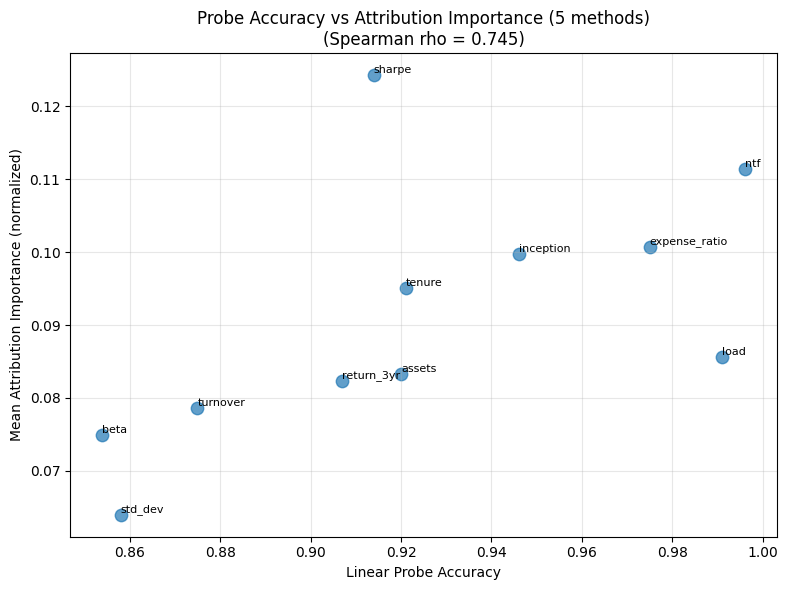

In [28]:
# Probe accuracy vs attribution importance (including LRP)
probe_best_path = PROJECT_ROOT / "data" / "probe_results" / "probe_best_layers_llama-3.2-3b_2_fewshot_cot_temp0.csv"

if probe_best_path.exists():
    probe_df = pd.read_csv(probe_best_path)
    probe_df["feature_short"] = probe_df["feature"].map(probe_feat_map)

    # Use all_methods if available, otherwise just LRP
    if interpreto_path.exists():
        avg_importance = all_methods.groupby("feature")["mean_norm"].mean().reset_index()
    else:
        avg_importance = lrp_combined.groupby("feature")["mean_norm"].mean().reset_index()
    avg_importance.columns = ["feature_short", "avg_attribution_importance"]

    comparison = probe_df.merge(avg_importance, on="feature_short", how="left")
    comparison = comparison.dropna(subset=["avg_attribution_importance"])

    if len(comparison) > 2:
        rho, p = spearmanr(comparison["test_accuracy"], comparison["avg_attribution_importance"])
        print(f"Probe accuracy vs attribution importance (all methods incl. LRP):")
        print(f"  Spearman rho = {rho:.3f} (p = {p:.4f})")
        print(f"\nDetailed comparison:")
        print(comparison[["feature", "test_accuracy", "avg_attribution_importance"]].to_string(index=False))

        # Also compute with LRP (AttnLRP) only
        lrp_avg = attnlrp_importance.set_index("feature")["mean_norm"]
        probe_short = probe_df.set_index("feature_short")["test_accuracy"]
        common = lrp_avg.index.intersection(probe_short.index)
        if len(common) > 3:
            rho_lrp, p_lrp = spearmanr(probe_short[common], lrp_avg[common])
            print(f"\nProbe accuracy vs LRP (AttnLRP) only: rho = {rho_lrp:.3f} (p = {p_lrp:.4f})")

        # Scatter plot
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(comparison["test_accuracy"], comparison["avg_attribution_importance"], s=80, alpha=0.7)
        for _, row in comparison.iterrows():
            ax.annotate(row["feature_short"],
                       (row["test_accuracy"], row["avg_attribution_importance"]),
                       fontsize=8, ha="left", va="bottom")
        ax.set_xlabel("Linear Probe Accuracy")
        ax.set_ylabel("Mean Attribution Importance (normalized)")
        n_methods = "5 methods" if interpreto_path.exists() else "2 LRP variants"
        ax.set_title(f"Probe Accuracy vs Attribution Importance ({n_methods})\n(Spearman rho = {rho:.3f})")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "probe_vs_attribution_with_lrp.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print(f"Probe results not found at {probe_best_path}")

## 13. Summary

In [29]:
print("=" * 70)
print("LRP ATTRIBUTION ANALYSIS SUMMARY")
print("=" * 70)
print(f"\nModel: Llama-3.2-3B-Instruct")
print(f"Prompt: Zero-shot template")
print(f"Samples analyzed: {len(df_sample)}")
print(f"Feature-order permutations: {N_PERMUTATIONS}")
print(f"Decimal truncation: 4 decimal places")
print(f"LRP Library: LXT (AttnLRP, ICML 2024)")
print(f"Precision: bfloat16 (no quantization)")

print(f"\nMethods run:")
print(f"  - LRP (AttnLRP) single-logit: {len(lrp_results)} samples")
print(f"  - LRP (CP-LRP) single-logit: {len(cplrp_results)} samples")
print(f"  - LRP-LogitDiff (AttnLRP): {len(logitdiff_results)} samples")
print(f"  - LRP-LogitDiff (CP-LRP): {len(logitdiff_cplrp_results)} samples")
print(f"  - Layer-wise analysis: {len(layer_feature_matrices)} samples")
print(f"  - Bootstrap CIs: {N_BOOTSTRAP} resamples")

if conservation_checks:
    ratios = [c["ratio"] for c in conservation_checks if not np.isnan(c["ratio"])]
    print(f"\nConservation check (single-logit AttnLRP):")
    print(f"  Mean ratio (relevance_sum / target_logit): {np.mean(ratios):.4f}")
    print(f"  Std: {np.std(ratios):.4f}")

if logitdiff_conservation:
    ratios_ld = [c["ratio"] for c in logitdiff_conservation if not np.isnan(c["ratio"])]
    print(f"\nConservation check (logit-diff AttnLRP):")
    print(f"  Mean ratio (relevance_sum / logit_diff): {np.mean(ratios_ld):.4f}")
    print(f"  Std: {np.std(ratios_ld):.4f}")

for label, imp_df in [
    ("LRP (AttnLRP)", attnlrp_importance),
    ("LRP (CP-LRP)", cplrp_importance),
    ("LRP-LogitDiff (AttnLRP)", logitdiff_attn_importance),
    ("LRP-LogitDiff (CP-LRP)", logitdiff_cplrp_importance),
]:
    if not imp_df.empty:
        print(f"\n--- {label} Feature Ranking ---")
        for _, row in imp_df.iterrows():
            print(f"  {int(row['rank']):2d}. {row['feature']:15s}  mean_norm={row['mean_norm']:.4f}")

print(f"\nOutputs saved to: {OUTPUT_DIR}")
print("  CSV files:")
for f in [
    "feature_importance_lrp_attnlrp.csv",
    "feature_importance_lrp_cplrp.csv",
    "feature_importance_lrp_logitdiff_attnlrp.csv",
    "feature_importance_lrp_logitdiff_cplrp.csv",
    "feature_importance_lrp_logitdiff_all.csv",
    "feature_importance_lrp_all.csv",
    "feature_importance_all_methods_with_lrp.csv",
    "layer_feature_relevance_attnlrp.csv",
    "lrp_probe_layer_correlation.csv",
    "bootstrap_ranking_confidence_intervals.csv",
]:
    print(f"  - {f}")
print("  Plots:")
for f in [
    "lrp_feature_importance_comparison.png",
    "lrp_token_heatmap_sample*.png",
    "lrp_layer_feature_heatmap.png",
    "lrp_total_relevance_by_layer.png",
    "lrp_vs_probe_by_layer.png",
    "lrp_signed_relevance.png",
    "fund1_vs_fund2_lrp_*.png",
    "all_methods_feature_importance.png",
    "probe_vs_attribution_with_lrp.png",
    "bootstrap_rank_distributions.png",
]:
    print(f"  - {f}")

LRP ATTRIBUTION ANALYSIS SUMMARY

Model: Llama-3.2-3B-Instruct
Prompt: Zero-shot template
Samples analyzed: 500
Feature-order permutations: 100
Decimal truncation: 4 decimal places
LRP Library: LXT (AttnLRP, ICML 2024)
Precision: bfloat16 (no quantization)

Methods run:
  - LRP (AttnLRP) single-logit: 500 samples
  - LRP (CP-LRP) single-logit: 500 samples
  - LRP-LogitDiff (AttnLRP): 500 samples
  - LRP-LogitDiff (CP-LRP): 500 samples
  - Layer-wise analysis: 200 samples
  - Bootstrap CIs: 1000 resamples

Conservation check (single-logit AttnLRP):
  Mean ratio (relevance_sum / target_logit): 0.6104
  Std: 0.0114

Conservation check (logit-diff AttnLRP):
  Mean ratio (relevance_sum / logit_diff): 0.6771
  Std: 0.0249

--- LRP (AttnLRP) Feature Ranking ---
   1. sharpe           mean_norm=0.2079
   2. return_3yr       mean_norm=0.1490
   3. expense_ratio    mean_norm=0.1068
   4. inception        mean_norm=0.1050
   5. assets           mean_norm=0.0863
   6. tenure           mean_norm=0.

In [30]:
# Clean up GPU memory
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU memory after cleanup: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
print("Done.")

GPU memory after cleanup: 0.02 GB
Done.
